# Passenger Boarding Simulation

This notebook will explore different boarding pass logic & which is more optimal under different conditons.


In [1]:
!rm -rf ../results/*
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import *
from pathlib import Path
from IPython.display import Image, display
from scipy import stats

### DO NOT EDIT BELOW THIS LINE ###
cwd = os.getcwd()
if os.path.basename(cwd) == "examples":
    repo_root = os.path.dirname(cwd)
else:
    repo_root = cwd

repo_root = Path(repo_root).resolve()
src_path = repo_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from simulation import SimConfig, run_once
from basic_strategies import STRATEGIES

### Uncomment below to use your custom strategy ###
# from custom_strategy import STRATEGIES, STRATEGY_NAME
# TEAM_NAME = STRATEGY_NAME

## Quick Unit Test for Strategies


In [2]:
# Run all simulations once to verify no errors occur
# use parallel execution

for strategy_name, strategy_func in STRATEGIES.items():
    print(f"Testing strategy: {strategy_name}")
    config = SimConfig(seed=174)

    metrics, plane, result = run_once(
        cfg=config,
        boarding_strategy=strategy_func,
        save_frames=False,
        perfect_queue=True,
    )
    print(f"Total ticks: {metrics.total_ticks}")
    print(f"Strategy {strategy_name} completed successfully.\n")

Testing strategy: front_to_back
Total ticks: 566
Strategy front_to_back completed successfully.

Testing strategy: back_to_front
Total ticks: 566
Strategy back_to_front completed successfully.

Testing strategy: random
Total ticks: 418
Strategy random completed successfully.

Testing strategy: wilma
Total ticks: 576
Strategy wilma completed successfully.

Testing strategy: steffen
Total ticks: 474
Strategy steffen completed successfully.



## Running Each Simulation 10 Times


In [3]:
!rm -rf ../results/*

for strategy_name, strategy_func in STRATEGIES.items():
    print(f"Running simulations for strategy: {strategy_name}")

    df = run_simulations_N(
        strategy_name=strategy_name,
        strategy_func=strategy_func,
        N=10
    )

    save_strategy_results(strategy_name, df, runs=10)
    print(f"Simulations for strategy {strategy_name} completed.\n")



Running simulations for strategy: front_to_back
Saved combined passenger results → ../results/front_to_back_passengers_10runs_combined.csv
Simulations for strategy front_to_back completed.

Running simulations for strategy: back_to_front
Saved combined passenger results → ../results/back_to_front_passengers_10runs_combined.csv
Simulations for strategy back_to_front completed.

Running simulations for strategy: random
Saved combined passenger results → ../results/random_passengers_10runs_combined.csv
Simulations for strategy random completed.

Running simulations for strategy: wilma
Saved combined passenger results → ../results/wilma_passengers_10runs_combined.csv
Simulations for strategy wilma completed.

Running simulations for strategy: steffen
Saved combined passenger results → ../results/steffen_passengers_10runs_combined.csv
Simulations for strategy steffen completed.



In [4]:
BtF_10_runs = pd.read_csv("../results/back_to_front_passengers_10runs_combined.csv")
FtB_10_runs = pd.read_csv("../results/front_to_back_passengers_10runs_combined.csv")
Steffen_10_runs = pd.read_csv("../results/steffen_passengers_10runs_combined.csv")
Wilma_10_runs = pd.read_csv("../results/wilma_passengers_10runs_combined.csv")
RandomOrder_10_runs = pd.read_csv("../results/random_passengers_10runs_combined.csv")
# custom_10_runs = pd.read_csv(f"../results/{TEAM_NAME}_passengers_10runs_combined.csv")

strategies = {
    "Back to Front": BtF_10_runs,
    "Front to Back": FtB_10_runs,
    "Steffen": Steffen_10_runs,
    "Wilma": Wilma_10_runs,
    "Random Order": RandomOrder_10_runs,
    # TEAM_NAME: custom_10_runs,
}

In [5]:
metrics_rows = []

for name, df in strategies.items():
    # Loop over all runs for this strategy
    for run in sorted(df["run"].unique()):
        run_df = df[df["run"] == run]

        total_passengers = len(run_df)
        missed_count = run_df["missed"].sum()
        missed_rate = missed_count / total_passengers if total_passengers > 0 else 0.0

        # time_to_seat stats
        tts = run_df["time_to_seat"].dropna()
        avg_tts = tts.mean() if not tts.empty else None
        median_tts = tts.median() if not tts.empty else None
        max_tts = tts.max() if not tts.empty else None

        # estimate total boarding time as max seat_time
        seat_times = run_df["seat_time"].dropna()
        total_ticks_est = seat_times.max() if not seat_times.empty else None

        metrics_rows.append(
            {
                "strategy": name,
                "run": int(run),
                "total_passengers": total_passengers,
                "missed_count": missed_count,
                "missed_rate": missed_rate,
                "total_ticks_est": total_ticks_est,
                "avg_time_to_seat": avg_tts,
                "median_time_to_seat": median_tts,
                "max_time_to_seat": max_tts,
            }
        )

metrics_df = pd.DataFrame(metrics_rows)
dashboard_df = metrics_df.copy()

In [6]:
import seaborn as sns

# Up to 10 distinct colors
strategy_palette = sns.color_palette("tab10", 10)

# Map each strategy name → its color
strategy_names = list(dashboard_df["strategy"].unique())
strategy_color_map = {
    name: strategy_palette[i % len(strategy_palette)]
    for i, name in enumerate(strategy_names)
}

# --- Build ranked summary for boarding time ---
ranked = (
    dashboard_df.groupby("strategy")["total_ticks_est"]
    .mean()
    .sort_values()
    .reset_index()
)

# --- Build per-passenger DF for stow_ticks histogram ---
# strategies is: { "Back to Front": BtF_10_runs, ... } (per-passenger data)
passenger_frames = []
for label, df_pass in strategies.items():
    tmp = df_pass.copy()
    tmp["strategy_label"] = label
    tmp["stow_ticks"] = pd.to_numeric(tmp["stow_ticks"], errors="coerce")
    passenger_frames.append(tmp)

all_passengers = pd.concat(passenger_frames, ignore_index=True)

# Only look at passengers who actually have a bag + valid stow time
stow_df = all_passengers[
    (all_passengers["has_bag"] == True) & (~all_passengers["stow_ticks"].isna())
]

/tmp/ipykernel_769801/2412828247.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_769801/2412828247.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_769801/2412828247.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


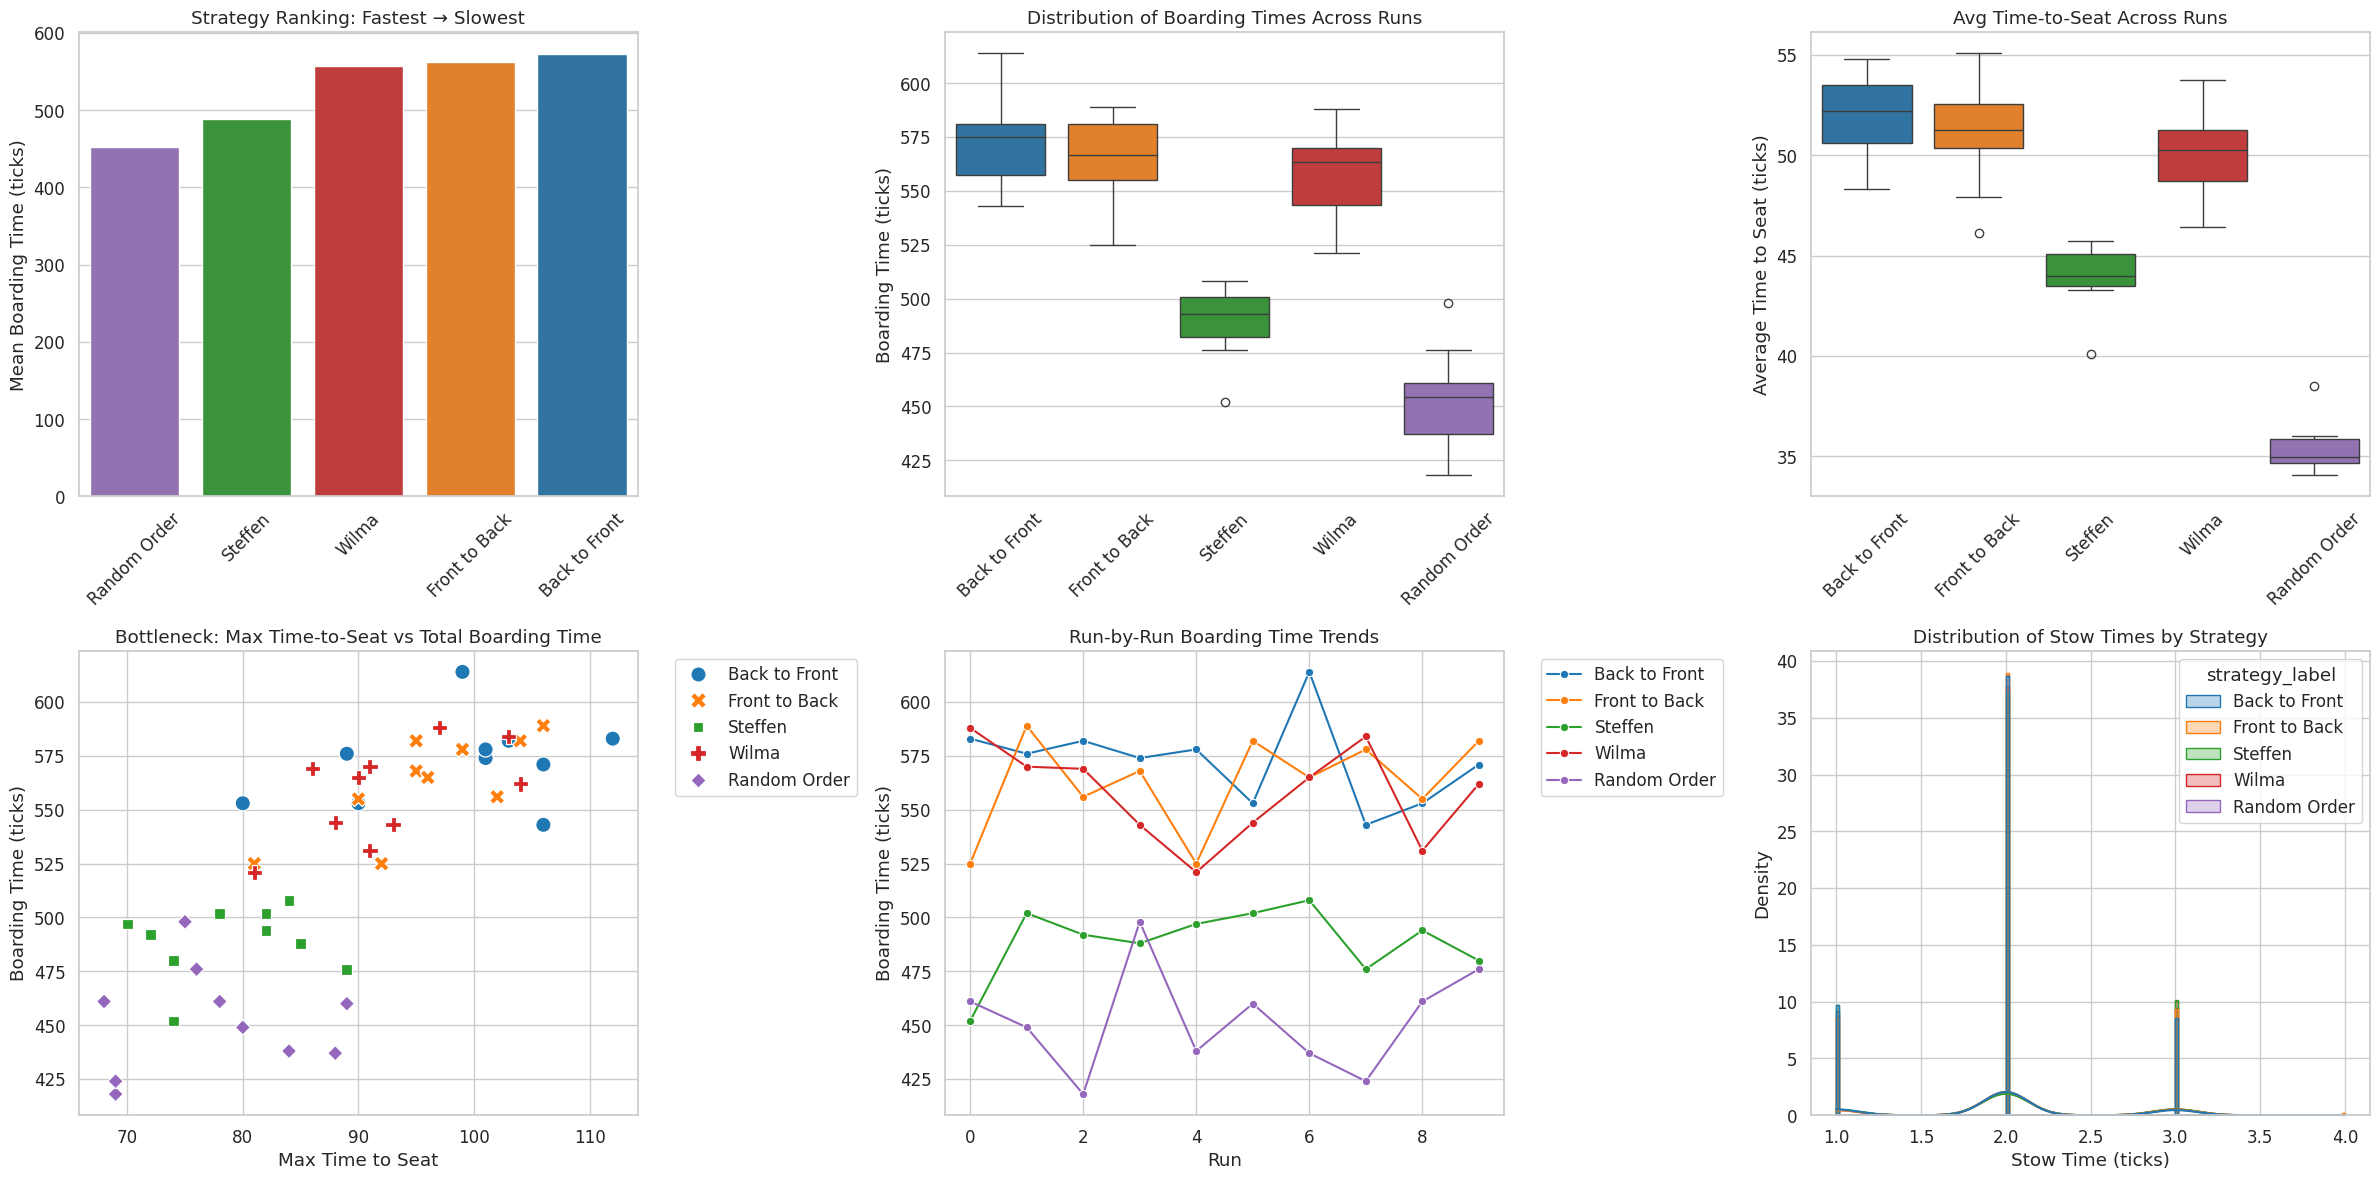

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid", font_scale=1.1)

# --- Create color map ---
strategy_names = list(dashboard_df["strategy"].unique())
strategy_palette = sns.color_palette("tab10", len(strategy_names))
strategy_color_map = {
    name: strategy_palette[i] for i, name in enumerate(strategy_names)
}


# --- Wrap seaborn's color param ---
def strat_colors(df, key="strategy"):
    return df[key].map(strategy_color_map)


# FIGURE
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

# ----------------------------
# 1. Strategy Ranking (top-left)
# ----------------------------
ranked = (
    dashboard_df.groupby("strategy")["total_ticks_est"]
    .mean()
    .sort_values()
    .reset_index()
)

sns.barplot(
    data=ranked,
    x="strategy",
    y="total_ticks_est",
    order=ranked["strategy"],
    palette=[strategy_color_map[s] for s in ranked["strategy"]],
    ax=ax1,
)
ax1.set_title("Strategy Ranking: Fastest → Slowest")
ax1.set_xlabel("")
ax1.set_ylabel("Mean Boarding Time (ticks)")
ax1.tick_params(axis="x", rotation=45)

# ----------------------------
# 2. Boxplot of Boarding Time
# ----------------------------
sns.boxplot(
    data=dashboard_df,
    x="strategy",
    y="total_ticks_est",
    palette=strategy_color_map,
    ax=ax2,
)
ax2.set_title("Distribution of Boarding Times Across Runs")
ax2.set_xlabel("")
ax2.set_ylabel("Boarding Time (ticks)")
ax2.tick_params(axis="x", rotation=45)

# ----------------------------
# 3. Boxplot of Avg Time-to-Seat
# ----------------------------
sns.boxplot(
    data=dashboard_df,
    x="strategy",
    y="avg_time_to_seat",
    palette=strategy_color_map,
    ax=ax3,
)
ax3.set_title("Avg Time-to-Seat Across Runs")
ax3.set_xlabel("")
ax3.set_ylabel("Average Time to Seat (ticks)")
ax3.tick_params(axis="x", rotation=45)

# ----------------------------
# 4. Bottleneck Scatter plot
# ----------------------------
sns.scatterplot(
    data=dashboard_df,
    x="max_time_to_seat",
    y="total_ticks_est",
    hue="strategy",
    palette=strategy_color_map,
    style="strategy",
    s=120,
    ax=ax4,
)
ax4.set_title("Bottleneck: Max Time-to-Seat vs Total Boarding Time")
ax4.set_xlabel("Max Time to Seat")
ax4.set_ylabel("Boarding Time (ticks)")
ax4.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# ----------------------------
# 5. Run-by-Run Trendlines
# ----------------------------
sns.lineplot(
    data=dashboard_df,
    x="run",
    y="total_ticks_est",
    hue="strategy",
    palette=strategy_color_map,
    marker="o",
    ax=ax5,
)
ax5.set_title("Run-by-Run Boarding Time Trends")
ax5.set_xlabel("Run")
ax5.set_ylabel("Boarding Time (ticks)")
ax5.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# ----------------------------
# 6. Histogram + KDE of stow_ticks
# ----------------------------
sns.histplot(
    data=stow_df,
    x="stow_ticks",
    hue="strategy_label",
    palette=[strategy_color_map[s] for s in stow_df["strategy_label"].unique()],
    stat="density",
    common_norm=False,
    kde=True,
    element="step",
    alpha=0.3,
    ax=ax6,
)
ax6.set_title("Distribution of Stow Times by Strategy")
ax6.set_xlabel("Stow Time (ticks)")
ax6.set_ylabel("Density")

plt.tight_layout()
plt.savefig("../figures/boarding_strategies_comparison.png")
plt.show()

## Detailed Comparative Analysis

### Statistical Comparison of Strategies


In [8]:
# Statistical Summary Table
from scipy import stats

print("=" * 100)
print("SUMMARY STATISTICS: BOARDING TIME BY STRATEGY (ticks)")
print("=" * 100)

summary_stats = []
for strategy in sorted(dashboard_df["strategy"].unique()):
    strat_data = dashboard_df[dashboard_df["strategy"] == strategy]["total_ticks_est"]

    summary_stats.append(
        {
            "Strategy": strategy,
            "Mean": f"{strat_data.mean():.1f}",
            "Median": f"{strat_data.median():.1f}",
            "Std Dev": f"{strat_data.std():.1f}",
            "Min": f"{strat_data.min():.0f}",
            "Max": f"{strat_data.max():.0f}",
            "Q1": f"{strat_data.quantile(0.25):.1f}",
            "Q3": f"{strat_data.quantile(0.75):.1f}",
        }
    )

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))
print()

# Compute improvements vs worst strategy (Front-to-Back)
worst_mean = dashboard_df[dashboard_df["strategy"] == "Front to Back"][
    "total_ticks_est"
].mean()
print(f"Reference (worst strategy): Front to Back = {worst_mean:.1f} ticks")
print("\nImprovement vs Front-to-Back (%):")
for strategy in sorted(dashboard_df["strategy"].unique()):
    if strategy != "Front to Back":
        strat_mean = dashboard_df[dashboard_df["strategy"] == strategy][
            "total_ticks_est"
        ].mean()
        improvement = ((worst_mean - strat_mean) / worst_mean) * 100
        print(f"  {strategy:20s}: {improvement:+6.1f}%")

SUMMARY STATISTICS: BOARDING TIME BY STRATEGY (ticks)
     Strategy  Mean Median Std Dev Min Max    Q1    Q3
Back to Front 572.7  575.0    20.0 543 614 557.5 581.0
Front to Back 562.5  566.5    22.7 525 589 555.2 581.0
 Random Order 452.2  454.5    24.2 418 498 437.2 461.0
      Steffen 489.1  493.0    16.4 452 508 482.0 500.8
        Wilma 557.7  563.5    22.2 521 588 543.2 569.8

Reference (worst strategy): Front to Back = 562.5 ticks

Improvement vs Front-to-Back (%):
  Back to Front       :   -1.8%
  Random Order        :  +19.6%
  Steffen             :  +13.0%
  Wilma               :   +0.9%


## Advanced Analysis: Passenger Entry Timing & Congestion Dynamics


ENTRY TIME ANALYSIS
     Strategy Mean Entry Time Median Entry Time Max Entry Time % Entered by tick 100
Back to Front           254.9             251.0            604                 27.2%
Front to Back           248.9             242.0            588                 28.0%
      Steffen           217.4             237.0            498                 28.0%
        Wilma           245.1             240.0            576                 28.4%
 Random Order           196.4             192.0            428                 28.0%



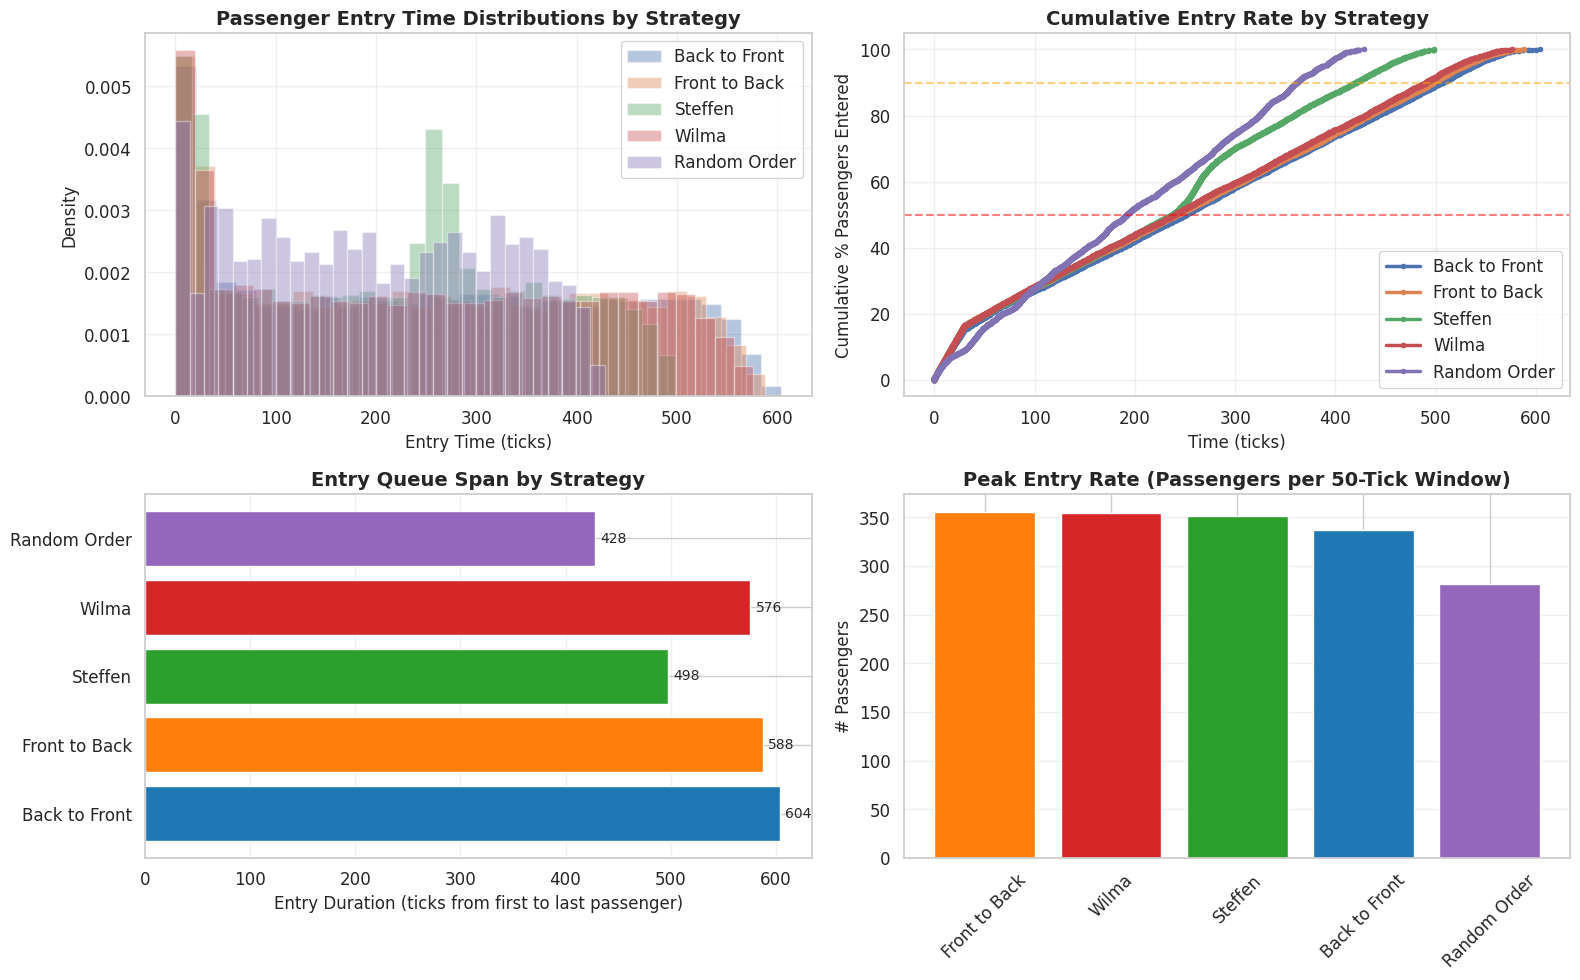

In [9]:
# 1. ENTRY TIME ANALYSIS: When do passengers enter the aisle?
print("=" * 100)
print("ENTRY TIME ANALYSIS")
print("=" * 100)

entry_analysis = []
for name, df in strategies.items():
    entry_times = pd.to_numeric(df["entry_time"], errors="coerce").dropna()

    entry_analysis.append(
        {
            "Strategy": name,
            "Mean Entry Time": f"{entry_times.mean():.1f}",
            "Median Entry Time": f"{entry_times.median():.1f}",
            "Max Entry Time": f"{entry_times.max():.0f}",
            "% Entered by tick 100": f"{(entry_times <= 100).sum() / len(entry_times) * 100:.1f}%",
        }
    )

entry_df = pd.DataFrame(entry_analysis)
print(entry_df.to_string(index=False))
print()

# Create visualization of entry time distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Entry time density (KDE)
ax1 = axes[0, 0]
for label, df_pass in strategies.items():
    entry_times = pd.to_numeric(df_pass["entry_time"], errors="coerce").dropna()
    ax1.hist(entry_times, bins=30, alpha=0.4, label=label, density=True)

ax1.set_xlabel("Entry Time (ticks)", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.set_title(
    "Passenger Entry Time Distributions by Strategy", fontsize=14, fontweight="bold"
)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cumulative % passengers entered
ax2 = axes[0, 1]
for label, df_pass in strategies.items():
    entry_times = pd.to_numeric(df_pass["entry_time"], errors="coerce").dropna()
    sorted_times = np.sort(entry_times)
    cumulative = np.arange(1, len(sorted_times) + 1) / len(sorted_times)
    ax2.plot(
        sorted_times,
        cumulative * 100,
        label=label,
        linewidth=2.5,
        marker="o",
        markersize=3,
    )

ax2.set_xlabel("Time (ticks)", fontsize=12)
ax2.set_ylabel("Cumulative % Passengers Entered", fontsize=12)
ax2.set_title("Cumulative Entry Rate by Strategy", fontsize=14, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=50, color="red", linestyle="--", alpha=0.5, label="50%")
ax2.axhline(y=90, color="orange", linestyle="--", alpha=0.5, label="90%")

# Plot 3: Entry delay (time from first to last passenger entering)
ax3 = axes[1, 0]
entry_ranges = []
entry_labels = []
for label, df_pass in strategies.items():
    entry_times = pd.to_numeric(df_pass["entry_time"], errors="coerce").dropna()
    entry_range = entry_times.max() - entry_times.min()
    entry_ranges.append(entry_range)
    entry_labels.append(label)

colors = [strategy_color_map[label] for label in entry_labels]
bars = ax3.barh(entry_labels, entry_ranges, color=colors)
ax3.set_xlabel("Entry Duration (ticks from first to last passenger)", fontsize=12)
ax3.set_title("Entry Queue Span by Strategy", fontsize=14, fontweight="bold")
ax3.grid(True, alpha=0.3, axis="x")

for i, (bar, val) in enumerate(zip(bars, entry_ranges)):
    ax3.text(val + 5, i, f"{val:.0f}", va="center", fontsize=10)

# Plot 4: Entry rate (passengers per tick)
ax4 = axes[1, 1]
entry_rate_data = []
for label, df_pass in strategies.items():
    entry_times = pd.to_numeric(df_pass["entry_time"], errors="coerce").dropna()
    # Bin into 50-tick windows
    hist, bins = np.histogram(
        entry_times, bins=np.arange(0, int(entry_times.max()) + 50, 50)
    )
    entry_rate_data.append(
        {"Strategy": label, "Peak Entry Rate (per 50 ticks)": hist.max()}
    )

entry_rate_df = pd.DataFrame(entry_rate_data).sort_values(
    "Peak Entry Rate (per 50 ticks)", ascending=False
)
colors_rate = [strategy_color_map[s] for s in entry_rate_df["Strategy"]]
ax4.bar(
    entry_rate_df["Strategy"],
    entry_rate_df["Peak Entry Rate (per 50 ticks)"],
    color=colors_rate,
)
ax4.set_ylabel("# Passengers", fontsize=12)
ax4.set_title(
    "Peak Entry Rate (Passengers per 50-Tick Window)", fontsize=14, fontweight="bold"
)
ax4.tick_params(axis="x", rotation=45)
ax4.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("../figures/entry_time_analysis.png")
plt.show()

## Seat Location Analysis: Row & Letter Performance


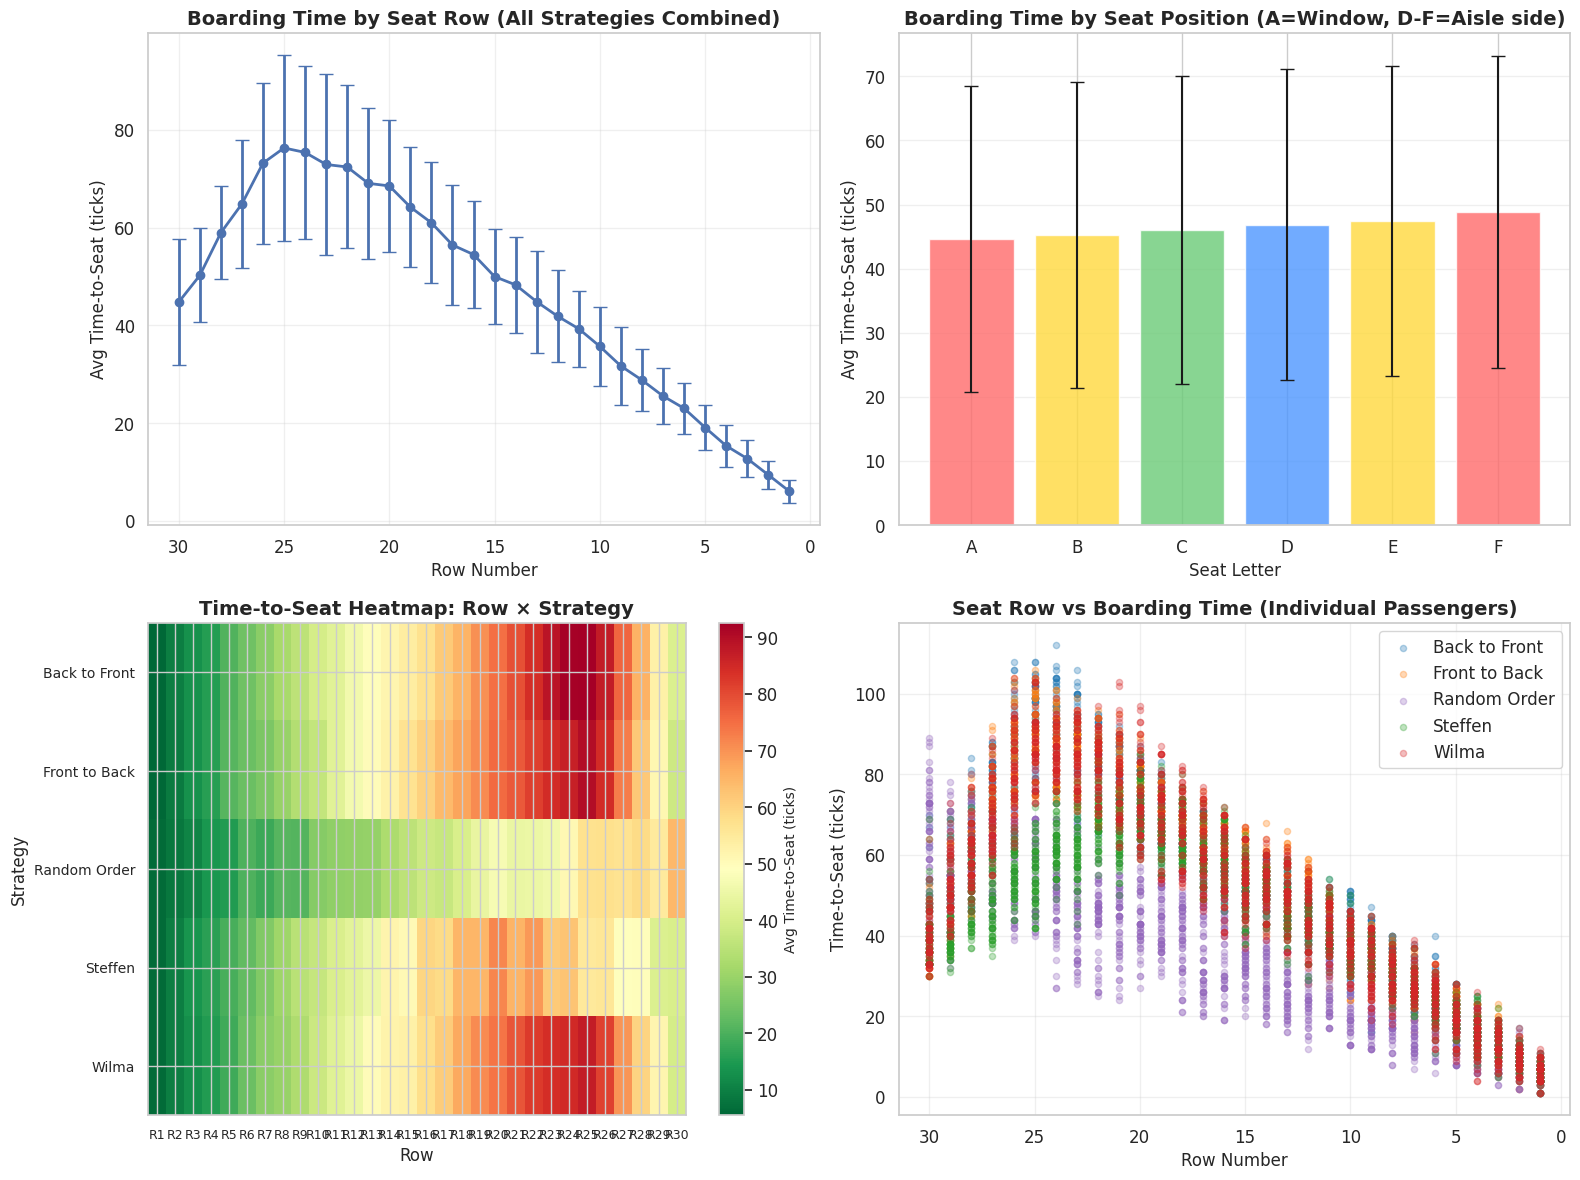


TIME-TO-SEAT BY SEAT LETTER:
                    mean        std
target_letter                      
A              44.630000  23.819530
B              45.222000  23.879633
C              46.012000  23.986901
D              46.888000  24.242317
E              47.427333  24.107402
F              48.795333  24.318108


Seat location categories:
  Window seats: A, F
  Middle seats: B, E
  Aisle seats: C, D


In [10]:
# Analyze impact of seat location on boarding time
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Time-to-seat by row (average across all strategies)
ax1 = axes[0, 0]
all_passengers["target_row"] = pd.to_numeric(
    all_passengers["target_row"], errors="coerce"
)
all_passengers["time_to_seat"] = pd.to_numeric(
    all_passengers["time_to_seat"], errors="coerce"
)

row_stats = (
    all_passengers[all_passengers["target_row"].notna()]
    .groupby("target_row")["time_to_seat"]
    .agg(["mean", "std", "count"])
)
ax1.errorbar(
    row_stats.index,
    row_stats["mean"],
    yerr=row_stats["std"],
    fmt="o-",
    linewidth=2,
    markersize=6,
    capsize=5,
)
ax1.set_xlabel("Row Number", fontsize=12)
ax1.set_ylabel("Avg Time-to-Seat (ticks)", fontsize=12)
ax1.set_title(
    "Boarding Time by Seat Row (All Strategies Combined)",
    fontsize=14,
    fontweight="bold",
)
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()  # Rear (row 1) on left, front on right

# Plot 2: Time-to-seat by seat letter
ax2 = axes[0, 1]
all_passengers["target_letter"] = all_passengers["target_letter"].astype(str)
letter_order = ["A", "B", "C", "D", "E", "F"]
all_passengers["target_letter"] = pd.Categorical(
    all_passengers["target_letter"], categories=letter_order, ordered=True
)

letter_stats = (
    all_passengers[all_passengers["target_letter"].notna()]
    .groupby("target_letter", observed=True)["time_to_seat"]
    .agg(["mean", "std"])
)
colors_letter = [
    "#FF6B6B",
    "#FFD93D",
    "#6BCB77",
    "#4D96FF",
    "#FFD93D",
    "#FF6B6B",
]  # Window, Middle, Aisle
ax2.bar(
    letter_stats.index,
    letter_stats["mean"],
    yerr=letter_stats["std"],
    color=colors_letter,
    capsize=5,
    alpha=0.8,
)
ax2.set_xlabel("Seat Letter", fontsize=12)
ax2.set_ylabel("Avg Time-to-Seat (ticks)", fontsize=12)
ax2.set_title(
    "Boarding Time by Seat Position (A=Window, D-F=Aisle side)",
    fontsize=14,
    fontweight="bold",
)
ax2.grid(True, alpha=0.3, axis="y")

# Plot 3: Time-to-seat by row + strategy heatmap
ax3 = axes[1, 0]
heatmap_data = []
for strategy in sorted(all_passengers["strategy_label"].unique()):
    strat_data = all_passengers[all_passengers["strategy_label"] == strategy]
    row_means = (
        strat_data[strat_data["target_row"].notna()]
        .groupby("target_row")["time_to_seat"]
        .mean()
    )
    heatmap_data.append(row_means)

heatmap_df = pd.DataFrame(
    heatmap_data, index=sorted(all_passengers["strategy_label"].unique())
).fillna(0)
im = ax3.imshow(
    heatmap_df.values, cmap="RdYlGn_r", aspect="auto", interpolation="nearest"
)
ax3.set_xticks(range(len(heatmap_df.columns)))
ax3.set_xticklabels([f"R{int(x)}" for x in heatmap_df.columns], fontsize=9)
ax3.set_yticks(range(len(heatmap_df.index)))
ax3.set_yticklabels(heatmap_df.index, fontsize=10)
ax3.set_xlabel("Row", fontsize=12)
ax3.set_ylabel("Strategy", fontsize=12)
ax3.set_title("Time-to-Seat Heatmap: Row × Strategy", fontsize=14, fontweight="bold")
cbar = plt.colorbar(im, ax=ax3)
cbar.set_label("Avg Time-to-Seat (ticks)", fontsize=10)

# Plot 4: Scatter: Seat row vs Time-to-seat, colored by strategy
ax4 = axes[1, 1]
for strategy in sorted(all_passengers["strategy_label"].unique()):
    strat_data = all_passengers[all_passengers["strategy_label"] == strategy]
    valid_data = strat_data[
        (strat_data["target_row"].notna()) & (strat_data["time_to_seat"].notna())
    ]
    ax4.scatter(
        valid_data["target_row"],
        valid_data["time_to_seat"],
        alpha=0.3,
        s=20,
        label=strategy,
        color=strategy_color_map[strategy],
    )

ax4.set_xlabel("Row Number", fontsize=12)
ax4.set_ylabel("Time-to-Seat (ticks)", fontsize=12)
ax4.set_title(
    "Seat Row vs Boarding Time (Individual Passengers)", fontsize=14, fontweight="bold"
)
ax4.legend(loc="best")
ax4.grid(True, alpha=0.3)
ax4.invert_xaxis()

plt.tight_layout()
plt.savefig("../figures/seat_location_analysis.png")
plt.show()

# Print summary statistics
print("\nTIME-TO-SEAT BY SEAT LETTER:")
print(letter_stats.to_string())
print("\n")
print("Seat location categories:")
print("  Window seats: A, F")
print("  Middle seats: B, E")
print("  Aisle seats: C, D")

## Baggage Impact Analysis: With Bag vs Without Bag


BAGGAGE IMPACT ANALYSIS
     Strategy With Bag (Mean) No Bag (Mean) Difference % Slower
Back to Front            52.8          48.0        4.8     9.9%
Front to Back            52.1          47.1        5.0    10.6%
 Random Order            36.1          32.3        3.8    11.8%
      Steffen            44.6          41.1        3.6     8.7%
        Wilma            51.4          45.9        5.4    11.9%


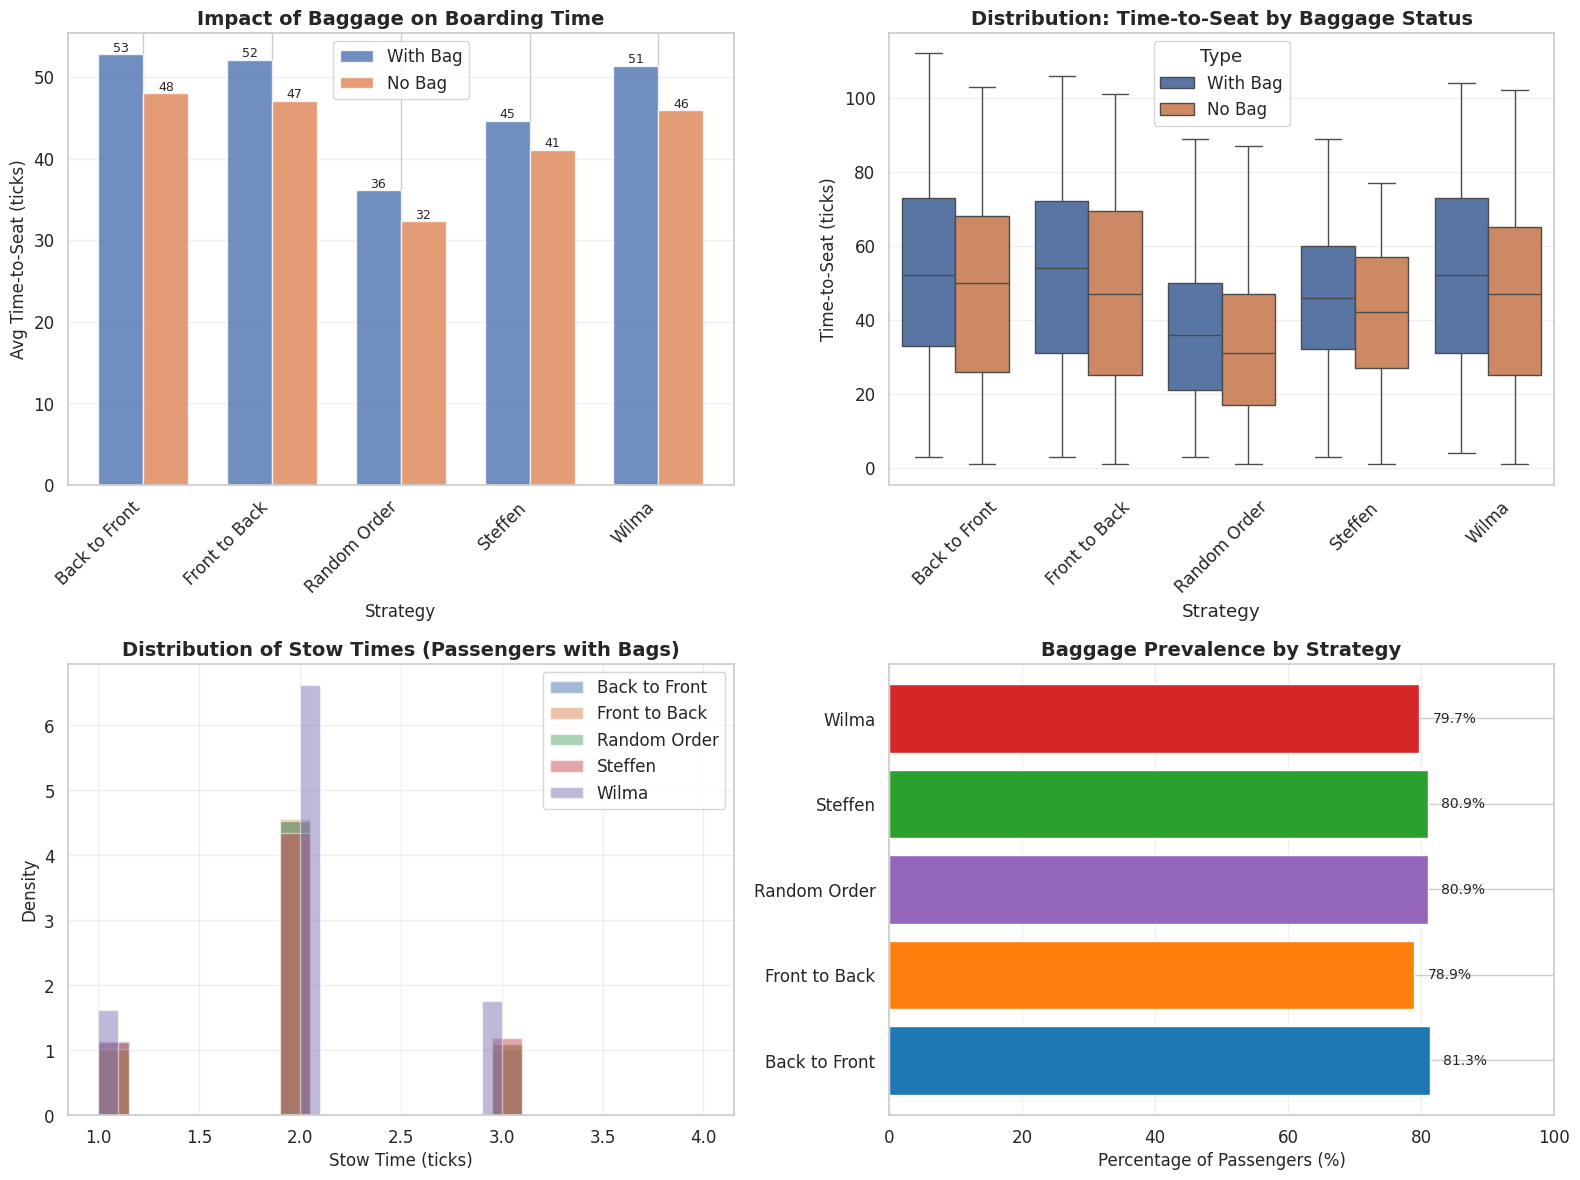

In [11]:
# Compare passengers with bags vs without
print("=" * 100)
print("BAGGAGE IMPACT ANALYSIS")
print("=" * 100)

all_passengers["has_bag"] = all_passengers["has_bag"].astype(bool)
all_passengers["time_to_seat"] = pd.to_numeric(
    all_passengers["time_to_seat"], errors="coerce"
)

baggage_comparison = []
for strategy in sorted(all_passengers["strategy_label"].unique()):
    strat_data = all_passengers[all_passengers["strategy_label"] == strategy]

    with_bag = strat_data[strat_data["has_bag"] == True]["time_to_seat"].dropna()
    no_bag = strat_data[strat_data["has_bag"] == False]["time_to_seat"].dropna()

    baggage_comparison.append(
        {
            "Strategy": strategy,
            "With Bag (Mean)": f"{with_bag.mean():.1f}",
            "No Bag (Mean)": f"{no_bag.mean():.1f}",
            "Difference": f"{with_bag.mean() - no_bag.mean():.1f}",
            "% Slower": f"{((with_bag.mean() - no_bag.mean()) / no_bag.mean() * 100):.1f}%",
        }
    )

baggage_df = pd.DataFrame(baggage_comparison)
print(baggage_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Comparison of time-to-seat with/without bags
ax1 = axes[0, 0]
comparison_data = []
for strategy in sorted(all_passengers["strategy_label"].unique()):
    strat_data = all_passengers[all_passengers["strategy_label"] == strategy]
    with_bag = strat_data[strat_data["has_bag"] == True]["time_to_seat"].mean()
    no_bag = strat_data[strat_data["has_bag"] == False]["time_to_seat"].mean()
    comparison_data.append(
        {"Strategy": strategy, "With Bag": with_bag, "No Bag": no_bag}
    )

comp_df = pd.DataFrame(comparison_data)
x = np.arange(len(comp_df))
width = 0.35

bars1 = ax1.bar(x - width / 2, comp_df["With Bag"], width, label="With Bag", alpha=0.8)
bars2 = ax1.bar(x + width / 2, comp_df["No Bag"], width, label="No Bag", alpha=0.8)

ax1.set_xlabel("Strategy", fontsize=12)
ax1.set_ylabel("Avg Time-to-Seat (ticks)", fontsize=12)
ax1.set_title("Impact of Baggage on Boarding Time", fontsize=14, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(comp_df["Strategy"], rotation=45, ha="right")
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

# Plot 2: Box plot comparison
ax2 = axes[0, 1]
plot_data = []
for strategy in sorted(all_passengers["strategy_label"].unique()):
    strat_data = all_passengers[all_passengers["strategy_label"] == strategy]
    with_bag = strat_data[strat_data["has_bag"] == True]["time_to_seat"].dropna()
    no_bag = strat_data[strat_data["has_bag"] == False]["time_to_seat"].dropna()
    for val in with_bag:
        plot_data.append({"Strategy": strategy, "Type": "With Bag", "Time": val})
    for val in no_bag:
        plot_data.append({"Strategy": strategy, "Type": "No Bag", "Time": val})

plot_df = pd.DataFrame(plot_data)
sns.boxplot(data=plot_df, x="Strategy", y="Time", hue="Type", ax=ax2)
ax2.set_title(
    "Distribution: Time-to-Seat by Baggage Status", fontsize=14, fontweight="bold"
)
ax2.set_ylabel("Time-to-Seat (ticks)", fontsize=12)
ax2.tick_params(axis="x", rotation=45)
ax2.grid(True, alpha=0.3, axis="y")

# Plot 3: Stow time distribution (only for passengers with bags)
ax3 = axes[1, 0]
for strategy in sorted(all_passengers["strategy_label"].unique()):
    strat_data = all_passengers[all_passengers["strategy_label"] == strategy]
    stow_times = pd.to_numeric(
        strat_data[strat_data["has_bag"] == True]["stow_ticks"], errors="coerce"
    ).dropna()
    if len(stow_times) > 0:
        ax3.hist(stow_times, bins=20, alpha=0.5, label=strategy, density=True)

ax3.set_xlabel("Stow Time (ticks)", fontsize=12)
ax3.set_ylabel("Density", fontsize=12)
ax3.set_title(
    "Distribution of Stow Times (Passengers with Bags)", fontsize=14, fontweight="bold"
)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Percentage passengers with bags by strategy
ax4 = axes[1, 1]
bag_percentages = []
for strategy in sorted(all_passengers["strategy_label"].unique()):
    strat_data = all_passengers[all_passengers["strategy_label"] == strategy]
    pct_with_bag = (strat_data["has_bag"].sum() / len(strat_data)) * 100
    bag_percentages.append({"Strategy": strategy, "% With Bag": pct_with_bag})

bag_pct_df = pd.DataFrame(bag_percentages)
colors_bag = [strategy_color_map[s] for s in bag_pct_df["Strategy"]]
bars = ax4.barh(bag_pct_df["Strategy"], bag_pct_df["% With Bag"], color=colors_bag)
ax4.set_xlabel("Percentage of Passengers (%)", fontsize=12)
ax4.set_title("Baggage Prevalence by Strategy", fontsize=14, fontweight="bold")
ax4.set_xlim([0, 100])
ax4.grid(True, alpha=0.3, axis="x")

for i, (bar, val) in enumerate(zip(bars, bag_pct_df["% With Bag"])):
    ax4.text(val + 2, i, f"{val:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("../figures/baggage_impact_analysis.png")
plt.show()

## Strategy Robustness & Variability Analysis


STRATEGY ROBUSTNESS ANALYSIS
     Strategy  Mean Std Dev CV (%) Best Run Worst Run Range
Back to Front 572.7    20.0   3.5%      543       614    71
Front to Back 562.5    22.7   4.0%      525       589    64
 Random Order 452.2    24.2   5.4%      418       498    80
      Steffen 489.1    16.4   3.4%      452       508    56
        Wilma 557.7    22.2   4.0%      521       588    67



/tmp/ipykernel_769801/2025176932.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


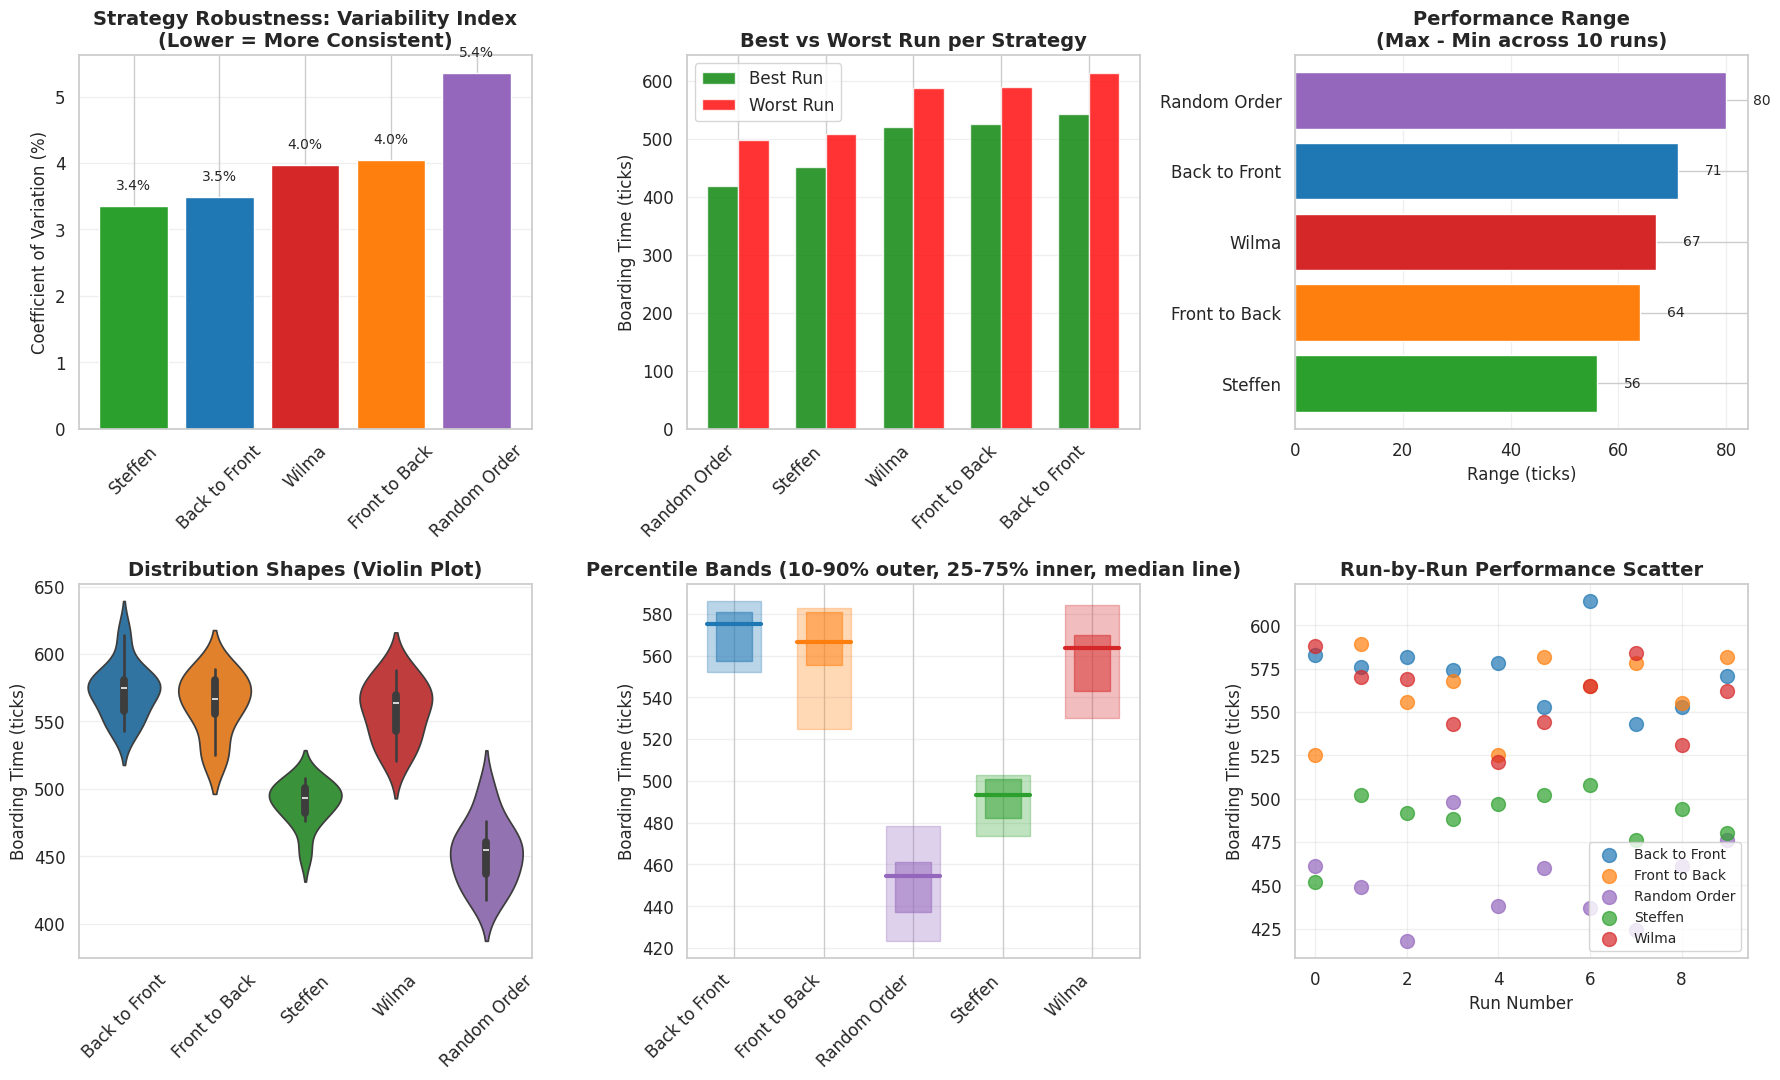

In [12]:
# Analyze robustness: coefficient of variation, worst/best case, etc.
print("=" * 100)
print("STRATEGY ROBUSTNESS ANALYSIS")
print("=" * 100)

robustness = []
for strategy in sorted(dashboard_df["strategy"].unique()):
    strat_data = dashboard_df[dashboard_df["strategy"] == strategy]["total_ticks_est"]
    mean_time = strat_data.mean()
    std_dev = strat_data.std()
    cv = (std_dev / mean_time) * 100  # Coefficient of variation

    robustness.append(
        {
            "Strategy": strategy,
            "Mean": f"{mean_time:.1f}",
            "Std Dev": f"{std_dev:.1f}",
            "CV (%)": f"{cv:.1f}%",
            "Best Run": f"{strat_data.min():.0f}",
            "Worst Run": f"{strat_data.max():.0f}",
            "Range": f"{strat_data.max() - strat_data.min():.0f}",
        }
    )

robustness_df = pd.DataFrame(robustness)
print(robustness_df.to_string(index=False))
print()

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Plot 1: Coefficient of Variation (lower is more robust)
ax1 = axes[0, 0]
cv_data = []
for strategy in sorted(dashboard_df["strategy"].unique()):
    strat_data = dashboard_df[dashboard_df["strategy"] == strategy]["total_ticks_est"]
    cv = (strat_data.std() / strat_data.mean()) * 100
    cv_data.append({"Strategy": strategy, "CV": cv})

cv_df = pd.DataFrame(cv_data).sort_values("CV")
colors_cv = [strategy_color_map[s] for s in cv_df["Strategy"]]
bars = ax1.bar(cv_df["Strategy"], cv_df["CV"], color=colors_cv)
ax1.set_ylabel("Coefficient of Variation (%)", fontsize=12)
ax1.set_title(
    "Strategy Robustness: Variability Index\n(Lower = More Consistent)",
    fontsize=14,
    fontweight="bold",
)
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars, cv_df["CV"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.2,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Plot 2: Best vs Worst case
ax2 = axes[0, 1]
best_worst = []
for strategy in sorted(dashboard_df["strategy"].unique()):
    strat_data = dashboard_df[dashboard_df["strategy"] == strategy]["total_ticks_est"]
    best_worst.append(
        {"Strategy": strategy, "Best": strat_data.min(), "Worst": strat_data.max()}
    )

bw_df = pd.DataFrame(best_worst).sort_values("Best")
x = np.arange(len(bw_df))
width = 0.35

ax2.bar(x - width / 2, bw_df["Best"], width, label="Best Run", alpha=0.8, color="green")
ax2.bar(x + width / 2, bw_df["Worst"], width, label="Worst Run", alpha=0.8, color="red")
ax2.set_ylabel("Boarding Time (ticks)", fontsize=12)
ax2.set_title("Best vs Worst Run per Strategy", fontsize=14, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(bw_df["Strategy"], rotation=45, ha="right")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

# Plot 3: Range (max - min)
ax3 = axes[0, 2]
range_data = []
for strategy in sorted(dashboard_df["strategy"].unique()):
    strat_data = dashboard_df[dashboard_df["strategy"] == strategy]["total_ticks_est"]
    range_val = strat_data.max() - strat_data.min()
    range_data.append({"Strategy": strategy, "Range": range_val})

range_df = pd.DataFrame(range_data).sort_values("Range")
colors_range = [strategy_color_map[s] for s in range_df["Strategy"]]
bars = ax3.barh(range_df["Strategy"], range_df["Range"], color=colors_range)
ax3.set_xlabel("Range (ticks)", fontsize=12)
ax3.set_title(
    "Performance Range\n(Max - Min across 10 runs)", fontsize=14, fontweight="bold"
)
ax3.grid(True, alpha=0.3, axis="x")

for bar, val in zip(bars, range_df["Range"]):
    ax3.text(
        val + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f}",
        va="center",
        fontsize=10,
    )

# Plot 4: Violin plot
ax4 = axes[1, 0]
sns.violinplot(
    data=dashboard_df,
    x="strategy",
    y="total_ticks_est",
    palette=strategy_color_map,
    ax=ax4,
)
ax4.set_title("Distribution Shapes (Violin Plot)", fontsize=14, fontweight="bold")
ax4.set_xlabel("")
ax4.set_ylabel("Boarding Time (ticks)", fontsize=12)
ax4.tick_params(axis="x", rotation=45)
ax4.grid(True, alpha=0.3, axis="y")

# Plot 5: Percentile bands
ax5 = axes[1, 1]
percentiles_plot = []
strategies_sorted = sorted(dashboard_df["strategy"].unique())
for i, strategy in enumerate(strategies_sorted):
    strat_data = dashboard_df[dashboard_df["strategy"] == strategy]["total_ticks_est"]
    p10 = strat_data.quantile(0.1)
    p25 = strat_data.quantile(0.25)
    p50 = strat_data.quantile(0.5)
    p75 = strat_data.quantile(0.75)
    p90 = strat_data.quantile(0.9)

    # Plot as a band
    ax5.fill_between(
        [i - 0.3, i + 0.3], p10, p90, alpha=0.3, color=strategy_color_map[strategy]
    )
    ax5.fill_between(
        [i - 0.2, i + 0.2], p25, p75, alpha=0.5, color=strategy_color_map[strategy]
    )
    ax5.plot(
        [i - 0.3, i + 0.3], [p50, p50], color=strategy_color_map[strategy], linewidth=3
    )

ax5.set_xticks(range(len(strategies_sorted)))
ax5.set_xticklabels(strategies_sorted, rotation=45, ha="right")
ax5.set_ylabel("Boarding Time (ticks)", fontsize=12)
ax5.set_title(
    "Percentile Bands (10-90% outer, 25-75% inner, median line)",
    fontsize=14,
    fontweight="bold",
)
ax5.grid(True, alpha=0.3, axis="y")

# Plot 6: Run-to-run consistency scatter
ax6 = axes[1, 2]
for strategy in strategies_sorted:
    strat_data = dashboard_df[dashboard_df["strategy"] == strategy]
    ax6.scatter(
        strat_data["run"],
        strat_data["total_ticks_est"],
        label=strategy,
        s=100,
        alpha=0.7,
        color=strategy_color_map[strategy],
    )

ax6.set_xlabel("Run Number", fontsize=12)
ax6.set_ylabel("Boarding Time (ticks)", fontsize=12)
ax6.set_title("Run-by-Run Performance Scatter", fontsize=14, fontweight="bold")
ax6.legend(loc="best", fontsize=10)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/strategy_robustness_analysis.png")
plt.show()

## Statistical Significance Testing


STATISTICAL SIGNIFICANCE TESTING (Two-Sample T-Tests)

Pairwise t-tests: Is the mean difference statistically significant?
Significance level: α = 0.05

   Strategy 1    Strategy 2 Mean Diff T-Statistic P-Value Significant
Back to Front Front to Back      10.2       1.065  0.3008          ns
Back to Front  Random Order     120.5      12.126  0.0000         ***
Back to Front       Steffen      83.6      10.224  0.0000         ***
Back to Front         Wilma      15.0       1.589  0.1296          ns
Front to Back  Random Order     110.3      10.497  0.0000         ***
Front to Back       Steffen      73.4       8.283  0.0000         ***
Front to Back         Wilma       4.8       0.478  0.6384          ns
 Random Order       Steffen     -36.9      -3.988  0.0009         ***
 Random Order         Wilma    -105.5     -10.156  0.0000         ***
      Steffen         Wilma     -68.6      -7.868  0.0000         ***

Significance codes: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant



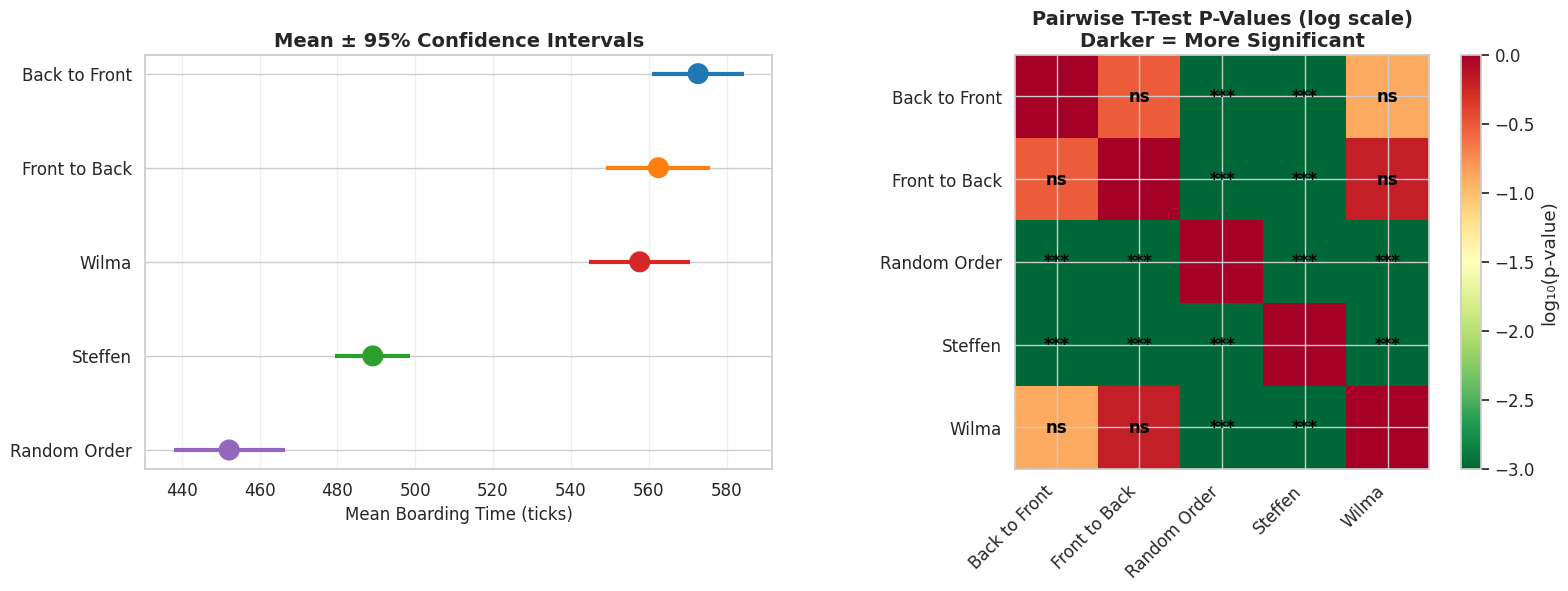

In [13]:
# Perform pairwise t-tests to see which strategies are significantly different
from scipy.stats import ttest_ind, f_oneway
import itertools

print("=" * 100)
print("STATISTICAL SIGNIFICANCE TESTING (Two-Sample T-Tests)")
print("=" * 100)
print()

strategies_list = sorted(dashboard_df["strategy"].unique())
print("Pairwise t-tests: Is the mean difference statistically significant?")
print("Significance level: α = 0.05\n")

# Get data for each strategy
strategy_data = {}
for strategy in strategies_list:
    strategy_data[strategy] = dashboard_df[dashboard_df["strategy"] == strategy][
        "total_ticks_est"
    ].values

# Perform pairwise comparisons
ttest_results = []
for strat1, strat2 in itertools.combinations(strategies_list, 2):
    t_stat, p_value = ttest_ind(strategy_data[strat1], strategy_data[strat2])
    mean_diff = strategy_data[strat1].mean() - strategy_data[strat2].mean()
    significant = (
        "***"
        if p_value < 0.001
        else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    )

    ttest_results.append(
        {
            "Strategy 1": strat1,
            "Strategy 2": strat2,
            "Mean Diff": f"{mean_diff:.1f}",
            "T-Statistic": f"{t_stat:.3f}",
            "P-Value": f"{p_value:.4f}",
            "Significant": significant,
        }
    )

ttest_df = pd.DataFrame(ttest_results)
print(ttest_df.to_string(index=False))
print("\nSignificance codes: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

# One-way ANOVA
print("\n" + "=" * 100)
print("ONE-WAY ANOVA: Testing overall differences across strategies")
print("=" * 100)
f_stat, p_anova = f_oneway(*[strategy_data[s] for s in strategies_list])
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_anova:.6f}")
print(
    f"Result: {'SIGNIFICANT' if p_anova < 0.05 else 'NOT SIGNIFICANT'} difference among strategies"
)

# Effect sizes (Cohen's d)
print("\n" + "=" * 100)
print("EFFECT SIZES (Cohen's d) - Steffen vs Other Strategies")
print("=" * 100)


def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    d = (np.mean(group1) - np.mean(group2)) / pooled_std
    return d


steffen_data = strategy_data["Steffen"]
effect_sizes = []
for strat in strategies_list:
    if strat != "Steffen":
        d = cohens_d(steffen_data, strategy_data[strat])
        interpretation = (
            "Large" if abs(d) > 0.8 else "Medium" if abs(d) > 0.5 else "Small"
        )
        effect_sizes.append(
            {
                "Steffen vs": strat,
                "Cohen's d": f"{d:.3f}",
                "Interpretation": interpretation,
            }
        )

effect_df = pd.DataFrame(effect_sizes)
print(effect_df.to_string(index=False))

# Visualization: Effect sizes and confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Confidence intervals for each strategy
ax1 = axes[0]
ci_data = []
for strategy in strategies_list:
    data = strategy_data[strategy]
    mean = data.mean()
    se = data.std() / np.sqrt(len(data))  # Standard error
    ci_lower = mean - 1.96 * se  # 95% CI
    ci_upper = mean + 1.96 * se
    ci_data.append(
        {"Strategy": strategy, "Mean": mean, "CI_Lower": ci_lower, "CI_Upper": ci_upper}
    )

ci_df = pd.DataFrame(ci_data).sort_values("Mean")
y_pos = np.arange(len(ci_df))

ax1.scatter(
    ci_df["Mean"],
    y_pos,
    s=200,
    color=[strategy_color_map[s] for s in ci_df["Strategy"]],
    zorder=3,
)
ax1.hlines(
    y_pos,
    ci_df["CI_Lower"],
    ci_df["CI_Upper"],
    colors=[strategy_color_map[s] for s in ci_df["Strategy"]],
    linewidth=3,
)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(ci_df["Strategy"])
ax1.set_xlabel("Mean Boarding Time (ticks)", fontsize=12)
ax1.set_title("Mean ± 95% Confidence Intervals", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3, axis="x")

# Plot 2: Pairwise comparison matrix
ax2 = axes[1]

# Create p-value matrix for visualization
n_strats = len(strategies_list)
p_matrix = np.ones((n_strats, n_strats))

for i, s1 in enumerate(strategies_list):
    for j, s2 in enumerate(strategies_list):
        if i != j:
            t_stat, p_val = ttest_ind(strategy_data[s1], strategy_data[s2])
            p_matrix[i, j] = p_val
        else:
            p_matrix[i, j] = 1.0

im = ax2.imshow(np.log10(p_matrix), cmap="RdYlGn_r", vmin=-3, vmax=0)
ax2.set_xticks(range(n_strats))
ax2.set_yticks(range(n_strats))
ax2.set_xticklabels(strategies_list, rotation=45, ha="right")
ax2.set_yticklabels(strategies_list)
ax2.set_title(
    "Pairwise T-Test P-Values (log scale)\nDarker = More Significant",
    fontsize=14,
    fontweight="bold",
)

# Add text annotations
for i in range(n_strats):
    for j in range(n_strats):
        if i != j:
            p_val = p_matrix[i, j]
            if p_val < 0.001:
                text = "***"
            elif p_val < 0.01:
                text = "**"
            elif p_val < 0.05:
                text = "*"
            else:
                text = "ns"
            ax2.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                color="black",
                fontsize=12,
                fontweight="bold",
            )

plt.colorbar(im, ax=ax2, label="log₁₀(p-value)")
plt.tight_layout()
plt.savefig("../figures/statistical_significance_analysis.png")
plt.show()

## Real-World Scenario Experiments

### Testing Different Operational Conditions

Based on the simulation parameters, we can experiment with various real-world scenarios that airlines face.


EXPERIMENT 1: CARRY-ON BAGGAGE RATE SENSITIVITY
Simulating: Business travel (60% bags) vs Leisure travel (90% bags)

Running Business Route (60% bags)...
Running Standard Route (80% bags)...
Running Holiday Route (90% bags)...

                 Scenario Bag Rate  Total Ticks  Passengers with Bags  Avg Stow Time
Business Route (60% bags)      60%          394                   111       2.021588
Standard Route (80% bags)      80%          474                   145       1.993510
 Holiday Route (90% bags)      90%          532                   164       2.018963



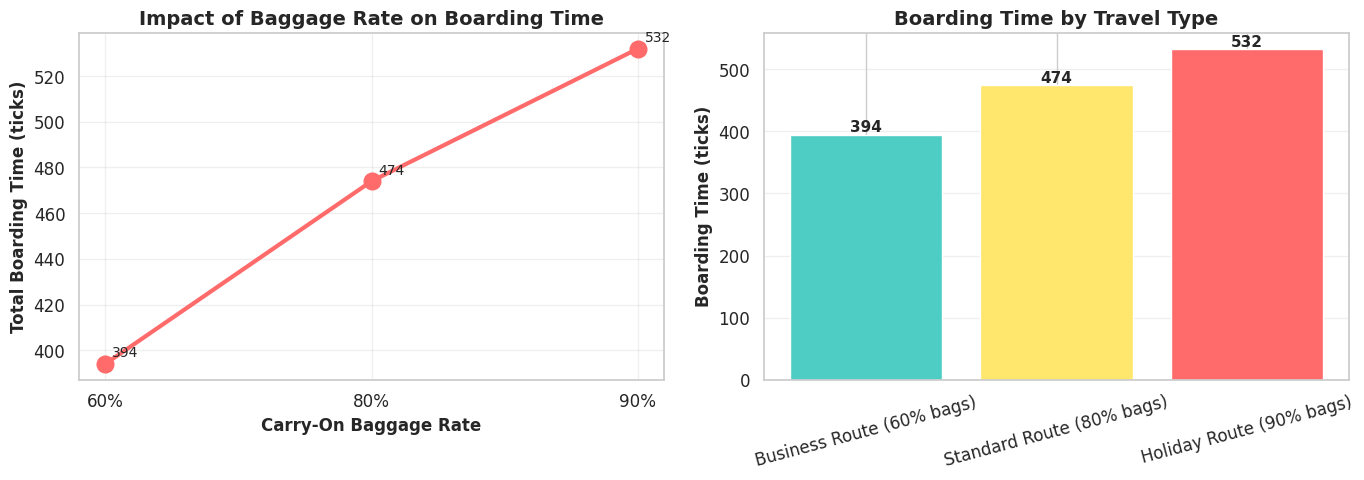

💡 INSIGHT: Higher baggage rates significantly increase boarding time.
   Holiday routes take ~35.0% longer than business routes!


In [14]:
# EXPERIMENT 1: Impact of Carry-On Baggage Rate (Holiday vs Business Travel)
# Business routes: lower baggage (60%), Leisure routes: higher baggage (90%)

print("=" * 100)
print("EXPERIMENT 1: CARRY-ON BAGGAGE RATE SENSITIVITY")
print("=" * 100)
print("Simulating: Business travel (60% bags) vs Leisure travel (90% bags)")
print()

baggage_scenarios = {
    "Business Route (60% bags)": 0.6,
    "Standard Route (80% bags)": 0.8,
    "Holiday Route (90% bags)": 0.9,
}

baggage_results = []

for scenario_name, bag_rate in baggage_scenarios.items():
    print(f"Running {scenario_name}...")

    # Run simulation with modified bag rate
    config = SimConfig(seed=174, num_passengers=180)
    config.p_have_bag = bag_rate

    metrics, plane, result = run_once(
        cfg=config,
        boarding_strategy=STRATEGIES["steffen"],  # Use best strategy
        save_frames=False,
        perfect_queue=True,
    )

    baggage_results.append(
        {
            "Scenario": scenario_name,
            "Bag Rate": f"{bag_rate*100:.0f}%",
            "Total Ticks": metrics.total_ticks,
            "Passengers with Bags": sum(
                1 for p in result if getattr(p, "has_bag", False)
            ),
            "Avg Stow Time": np.mean(
                [
                    p.stow_ticks_continuous
                    for p in result
                    if getattr(p, "has_bag", False) and p.stow_ticks_continuous
                ]
            ),
        }
    )

baggage_exp_df = pd.DataFrame(baggage_results)
print()
print(baggage_exp_df.to_string(index=False))
print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(
    baggage_exp_df["Bag Rate"],
    baggage_exp_df["Total Ticks"],
    marker="o",
    linewidth=3,
    markersize=12,
    color="#FF6B6B",
)
ax1.set_xlabel("Carry-On Baggage Rate", fontsize=12, fontweight="bold")
ax1.set_ylabel("Total Boarding Time (ticks)", fontsize=12, fontweight="bold")
ax1.set_title("Impact of Baggage Rate on Boarding Time", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)
for i, row in baggage_exp_df.iterrows():
    ax1.annotate(
        f"{row['Total Ticks']}",
        xy=(row["Bag Rate"], row["Total Ticks"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
    )

ax2 = axes[1]
colors = ["#4ECDC4", "#FFE66D", "#FF6B6B"]
bars = ax2.bar(baggage_exp_df["Scenario"], baggage_exp_df["Total Ticks"], color=colors)
ax2.set_ylabel("Boarding Time (ticks)", fontsize=12, fontweight="bold")
ax2.set_title("Boarding Time by Travel Type", fontsize=14, fontweight="bold")
ax2.tick_params(axis="x", rotation=15)
ax2.grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars, baggage_exp_df["Total Ticks"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        val + 5,
        f"{val}",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../figures/baggage_rate_sensitivity_analysis.png")
plt.show()

print("💡 INSIGHT: Higher baggage rates significantly increase boarding time.")
print(
    f"   Holiday routes take ~{((baggage_exp_df.iloc[2]['Total Ticks'] - baggage_exp_df.iloc[0]['Total Ticks']) / baggage_exp_df.iloc[0]['Total Ticks'] * 100):.1f}% longer than business routes!"
)


EXPERIMENT 2: WALKING SPEED SENSITIVITY
Simulating: Fast walkers (commuters) vs Slow walkers (elderly/families)

Running Fast Walkers (Commuters)...
Running Standard Pace...
Running Slow Walkers (Families)...

                Scenario  Walk Mean  Total Ticks  Avg Walk Ticks
Fast Walkers (Commuters)        0.7          474        1.000000
           Standard Pace        1.0          474        1.000000
 Slow Walkers (Families)        1.4          582        1.311111



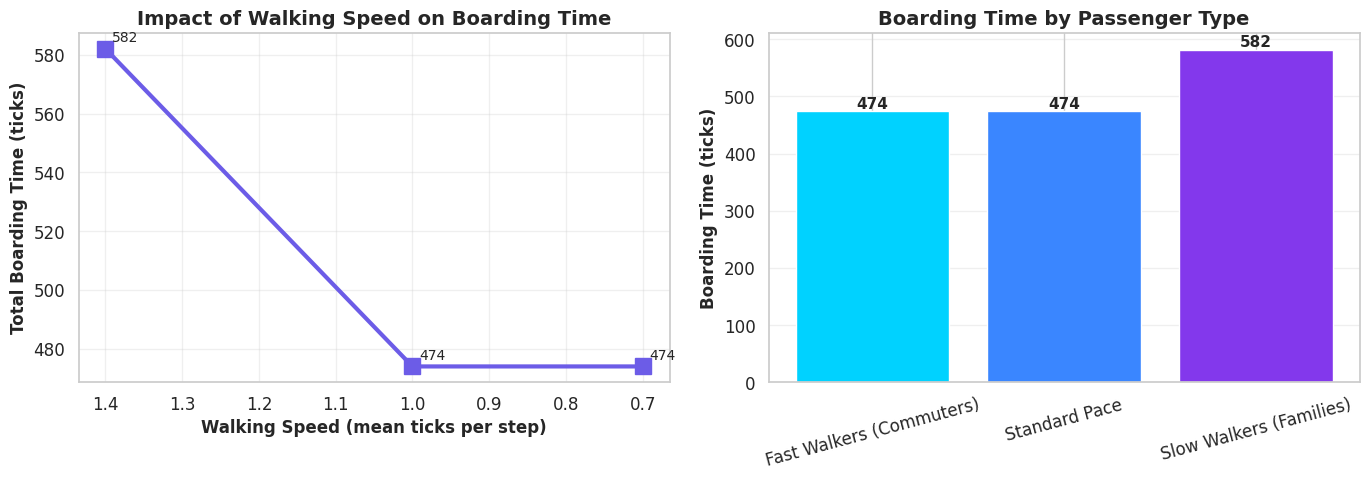

💡 INSIGHT: Walking speed has significant impact on boarding time.
   Families/elderly flights take ~22.8% longer!


In [15]:
# EXPERIMENT 2: Impact of Passenger Walking Speed (Rush Hour vs Elderly/Families)
# Fast walkers (morning commuters): walk_mean=0.8, Slow walkers (elderly/families): walk_mean=1.5

print("\n" + "=" * 100)
print("EXPERIMENT 2: WALKING SPEED SENSITIVITY")
print("=" * 100)
print("Simulating: Fast walkers (commuters) vs Slow walkers (elderly/families)")
print()

walking_scenarios = {
    "Fast Walkers (Commuters)": {"mean": 0.7, "sd": 0.15},
    "Standard Pace": {"mean": 1.0, "sd": 0.2},
    "Slow Walkers (Families)": {"mean": 1.4, "sd": 0.3},
}

walking_results = []

for scenario_name, walk_params in walking_scenarios.items():
    print(f"Running {scenario_name}...")

    config = SimConfig(seed=174, num_passengers=180)
    config.walk_mean = walk_params["mean"]
    config.walk_sd = walk_params["sd"]

    metrics, plane, result = run_once(
        cfg=config,
        boarding_strategy=STRATEGIES["steffen"],
        save_frames=False,
        perfect_queue=True,
    )

    walking_results.append(
        {
            "Scenario": scenario_name,
            "Walk Mean": walk_params["mean"],
            "Total Ticks": metrics.total_ticks,
            "Avg Walk Ticks": np.mean([p.walk_ticks for p in result]),
        }
    )

walking_exp_df = pd.DataFrame(walking_results)
print()
print(walking_exp_df.to_string(index=False))
print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(
    walking_exp_df["Walk Mean"],
    walking_exp_df["Total Ticks"],
    marker="s",
    linewidth=3,
    markersize=12,
    color="#6C5CE7",
)
ax1.set_xlabel("Walking Speed (mean ticks per step)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Total Boarding Time (ticks)", fontsize=12, fontweight="bold")
ax1.set_title(
    "Impact of Walking Speed on Boarding Time", fontsize=14, fontweight="bold"
)
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()  # Lower is faster
for i, row in walking_exp_df.iterrows():
    ax1.annotate(
        f"{row['Total Ticks']}",
        xy=(row["Walk Mean"], row["Total Ticks"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
    )

ax2 = axes[1]
colors = ["#00D2FF", "#3A86FF", "#8338EC"]
bars = ax2.bar(walking_exp_df["Scenario"], walking_exp_df["Total Ticks"], color=colors)
ax2.set_ylabel("Boarding Time (ticks)", fontsize=12, fontweight="bold")
ax2.set_title("Boarding Time by Passenger Type", fontsize=14, fontweight="bold")
ax2.tick_params(axis="x", rotation=15)
ax2.grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars, walking_exp_df["Total Ticks"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        val + 5,
        f"{val}",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../figures/walking_speed_sensitivity_analysis.png")
plt.show()

print("💡 INSIGHT: Walking speed has significant impact on boarding time.")
print(
    f"   Families/elderly flights take ~{((walking_exp_df.iloc[2]['Total Ticks'] - walking_exp_df.iloc[0]['Total Ticks']) / walking_exp_df.iloc[0]['Total Ticks'] * 100):.1f}% longer!"
)


EXPERIMENT 3: STOW TIME SENSITIVITY
Simulating: Experienced travelers vs Inexperienced travelers

Running Experienced Travelers...
Running Standard Travelers...
Running Inexperienced Travelers...

               Scenario  Stow Mean  Total Ticks  Avg Stow Time
  Experienced Travelers        1.5          426       1.499953
     Standard Travelers        2.0          474       1.993510
Inexperienced Travelers        3.0          566       2.982856



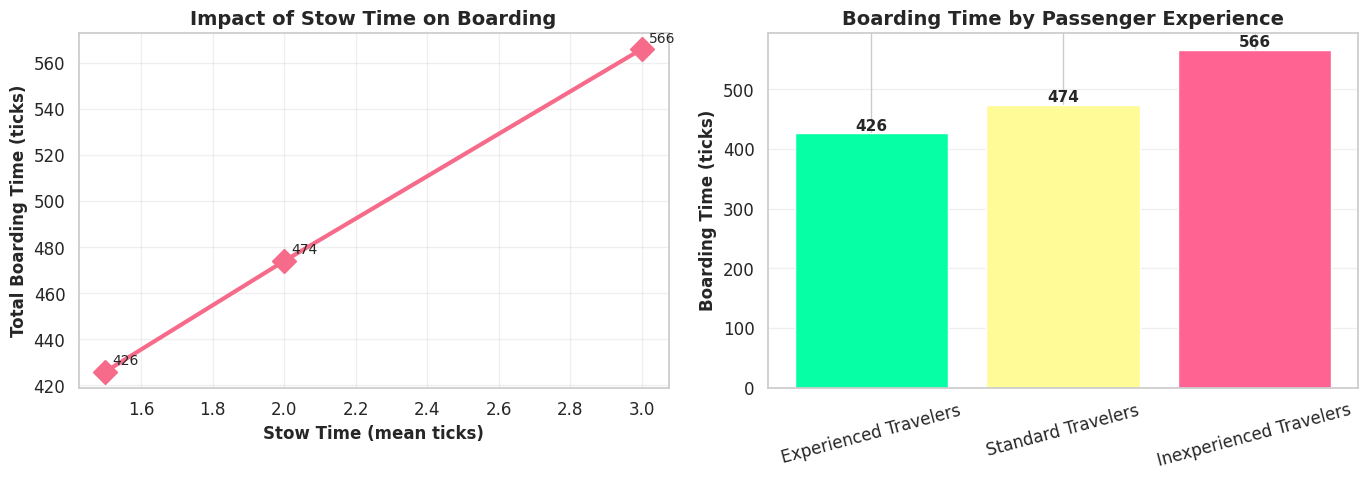

💡 INSIGHT: Stow time is THE DOMINANT factor in boarding delays!
   Inexperienced travelers take ~32.9% longer to board!


In [16]:
# EXPERIMENT 3: Impact of Stow Time (Experienced vs Inexperienced Travelers)
# Experienced travelers: stow_mean=1.5, Inexperienced: stow_mean=3.0

print("\n" + "=" * 100)
print("EXPERIMENT 3: STOW TIME SENSITIVITY")
print("=" * 100)
print("Simulating: Experienced travelers vs Inexperienced travelers")
print()

stow_scenarios = {
    "Experienced Travelers": {"mean": 1.5, "sd": 0.3},
    "Standard Travelers": {"mean": 2.0, "sd": 0.5},
    "Inexperienced Travelers": {"mean": 3.0, "sd": 0.8},
}

stow_results = []

for scenario_name, stow_params in stow_scenarios.items():
    print(f"Running {scenario_name}...")

    config = SimConfig(seed=174, num_passengers=180)
    config.stow_mean = stow_params["mean"]
    config.stow_sd = stow_params["sd"]

    metrics, plane, result = run_once(
        cfg=config,
        boarding_strategy=STRATEGIES["steffen"],
        save_frames=False,
        perfect_queue=True,
    )

    stow_results.append(
        {
            "Scenario": scenario_name,
            "Stow Mean": stow_params["mean"],
            "Total Ticks": metrics.total_ticks,
            "Avg Stow Time": np.mean(
                [
                    p.stow_ticks_continuous
                    for p in result
                    if getattr(p, "has_bag", False) and p.stow_ticks_continuous
                ]
            ),
        }
    )

stow_exp_df = pd.DataFrame(stow_results)
print()
print(stow_exp_df.to_string(index=False))
print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(
    stow_exp_df["Stow Mean"],
    stow_exp_df["Total Ticks"],
    marker="D",
    linewidth=3,
    markersize=12,
    color="#F76B8A",
)
ax1.set_xlabel("Stow Time (mean ticks)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Total Boarding Time (ticks)", fontsize=12, fontweight="bold")
ax1.set_title("Impact of Stow Time on Boarding", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)
for i, row in stow_exp_df.iterrows():
    ax1.annotate(
        f"{row['Total Ticks']}",
        xy=(row["Stow Mean"], row["Total Ticks"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
    )

ax2 = axes[1]
colors = ["#06FFA5", "#FFFB96", "#FF6392"]
bars = ax2.bar(stow_exp_df["Scenario"], stow_exp_df["Total Ticks"], color=colors)
ax2.set_ylabel("Boarding Time (ticks)", fontsize=12, fontweight="bold")
ax2.set_title("Boarding Time by Passenger Experience", fontsize=14, fontweight="bold")
ax2.tick_params(axis="x", rotation=15)
ax2.grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars, stow_exp_df["Total Ticks"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        val + 5,
        f"{val}",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../figures/stow_time_sensitivity_analysis.png")
plt.show()

print("💡 INSIGHT: Stow time is THE DOMINANT factor in boarding delays!")
print(
    f"   Inexperienced travelers take ~{((stow_exp_df.iloc[2]['Total Ticks'] - stow_exp_df.iloc[0]['Total Ticks']) / stow_exp_df.iloc[0]['Total Ticks'] * 100):.1f}% longer to board!"
)


EXPERIMENT 4: NO-SHOW RATE SENSITIVITY
Simulating: Normal conditions vs Weather delays/Missed connections

Running Perfect Conditions (1% no-show)...
Running Normal Conditions (2% no-show)...
Running Weather/Connections (8% no-show)...

                        Scenario No-Show Rate  Expected No-Shows  Actual Boarded  Total Ticks
 Perfect Conditions (1% no-show)           1%                  1             178          475
  Normal Conditions (2% no-show)           2%                  3             174          453
Weather/Connections (8% no-show)           8%                 14             167          442



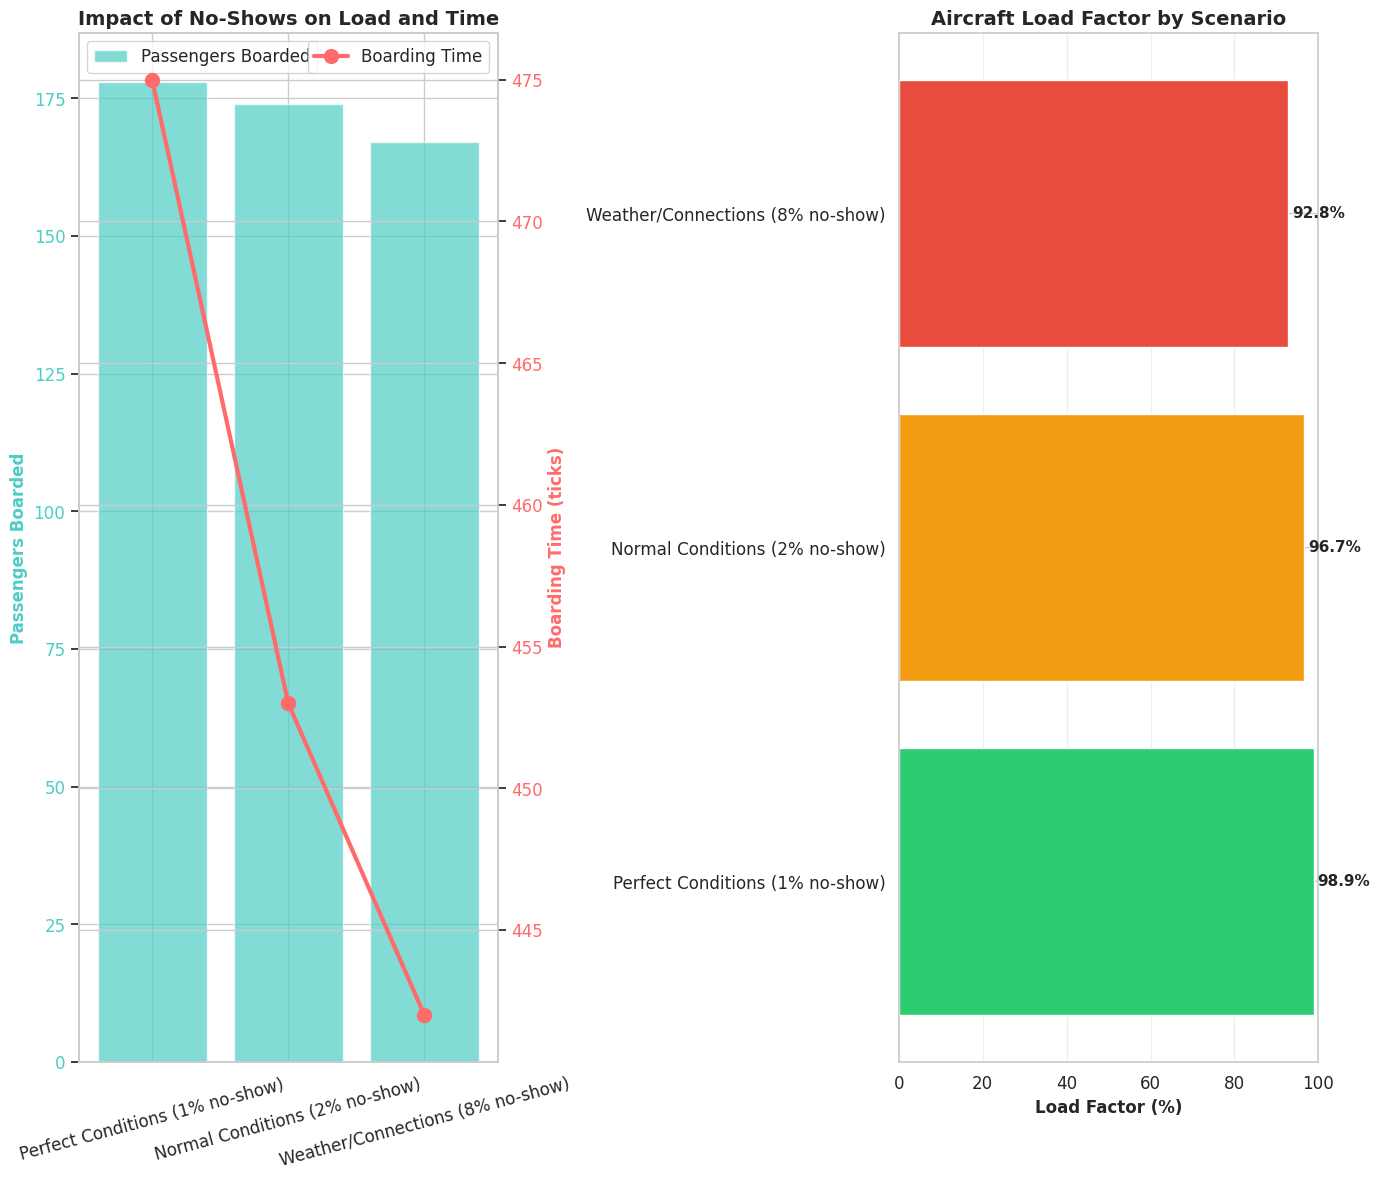

💡 INSIGHT: No-shows reduce boarding time but hurt revenue (empty seats).
   High no-show scenarios lose 14 passengers = significant revenue loss!


In [17]:
# EXPERIMENT 4: Impact of No-Show Rate (Weather Delays, Connections)
# Good weather: 1% no-show, Bad weather/connections: 10% no-show

print("\n" + "=" * 100)
print("EXPERIMENT 4: NO-SHOW RATE SENSITIVITY")
print("=" * 100)
print("Simulating: Normal conditions vs Weather delays/Missed connections")
print()

noshow_scenarios = {
    "Perfect Conditions (1% no-show)": 0.01,
    "Normal Conditions (2% no-show)": 0.02,
    "Weather/Connections (8% no-show)": 0.08,
}

noshow_results = []

for scenario_name, noshow_rate in noshow_scenarios.items():
    print(f"Running {scenario_name}...")

    config = SimConfig(
        seed=174, num_passengers=180, disable_no_shows_when_filling=False
    )
    config.p_missed = noshow_rate

    metrics, plane, result = run_once(
        cfg=config,
        boarding_strategy=STRATEGIES["steffen"],
        save_frames=False,
        perfect_queue=True,
    )

    missed_count = sum(1 for p in result if getattr(p, "missed", False))
    actual_boarded = len([p for p in result if not getattr(p, "missed", False)])

    noshow_results.append(
        {
            "Scenario": scenario_name,
            "No-Show Rate": f"{noshow_rate*100:.0f}%",
            "Expected No-Shows": int(180 * noshow_rate),
            "Actual Boarded": actual_boarded,
            "Total Ticks": metrics.total_ticks,
        }
    )

noshow_exp_df = pd.DataFrame(noshow_results)
print()
print(noshow_exp_df.to_string(index=False))
print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.bar(
    noshow_exp_df["Scenario"],
    noshow_exp_df["Actual Boarded"],
    alpha=0.7,
    color="#4ECDC4",
    label="Passengers Boarded",
)
ax1_twin.plot(
    noshow_exp_df["Scenario"],
    noshow_exp_df["Total Ticks"],
    color="#FF6B6B",
    marker="o",
    linewidth=3,
    markersize=10,
    label="Boarding Time",
)
ax1.set_ylabel("Passengers Boarded", fontsize=12, fontweight="bold", color="#4ECDC4")
ax1_twin.set_ylabel(
    "Boarding Time (ticks)", fontsize=12, fontweight="bold", color="#FF6B6B"
)
ax1.set_title("Impact of No-Shows on Load and Time", fontsize=14, fontweight="bold")
ax1.tick_params(axis="x", rotation=15)
ax1.tick_params(axis="y", labelcolor="#4ECDC4")
ax1_twin.tick_params(axis="y", labelcolor="#FF6B6B")
ax1.legend(loc="upper left")
ax1_twin.legend(loc="upper right")

ax2 = axes[1]
load_factors = [
    row["Actual Boarded"] / 180 * 100 for _, row in noshow_exp_df.iterrows()
]
colors_load = ["#2ECC71", "#F39C12", "#E74C3C"]
bars = ax2.barh(noshow_exp_df["Scenario"], load_factors, color=colors_load)
ax2.set_xlabel("Load Factor (%)", fontsize=12, fontweight="bold")
ax2.set_title("Aircraft Load Factor by Scenario", fontsize=14, fontweight="bold")
ax2.set_xlim([0, 100])
ax2.grid(True, alpha=0.3, axis="x")

for bar, val in zip(bars, load_factors):
    ax2.text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../figures/no_show_rate_sensitivity_analysis.png")
plt.show()

print("💡 INSIGHT: No-shows reduce boarding time but hurt revenue (empty seats).")
print(
    f"   High no-show scenarios lose {noshow_exp_df.iloc[2]['Expected No-Shows']} passengers = significant revenue loss!"
)


EXPERIMENT 5: COMBINED WORST-CASE vs BEST-CASE SCENARIOS

Running BEST CASE...
Running AVERAGE CASE...
Running WORST CASE...

                                      Scenario Bag Rate  Walk Speed  Stow Time  Total Ticks
      BEST CASE\n(Business, Fast, Experienced)      60%         0.7        1.5          359
           AVERAGE CASE\n(Standard conditions)      80%         1.0        2.0          474
WORST CASE\n(Holiday, Families, Inexperienced)      95%         1.5        3.5          847



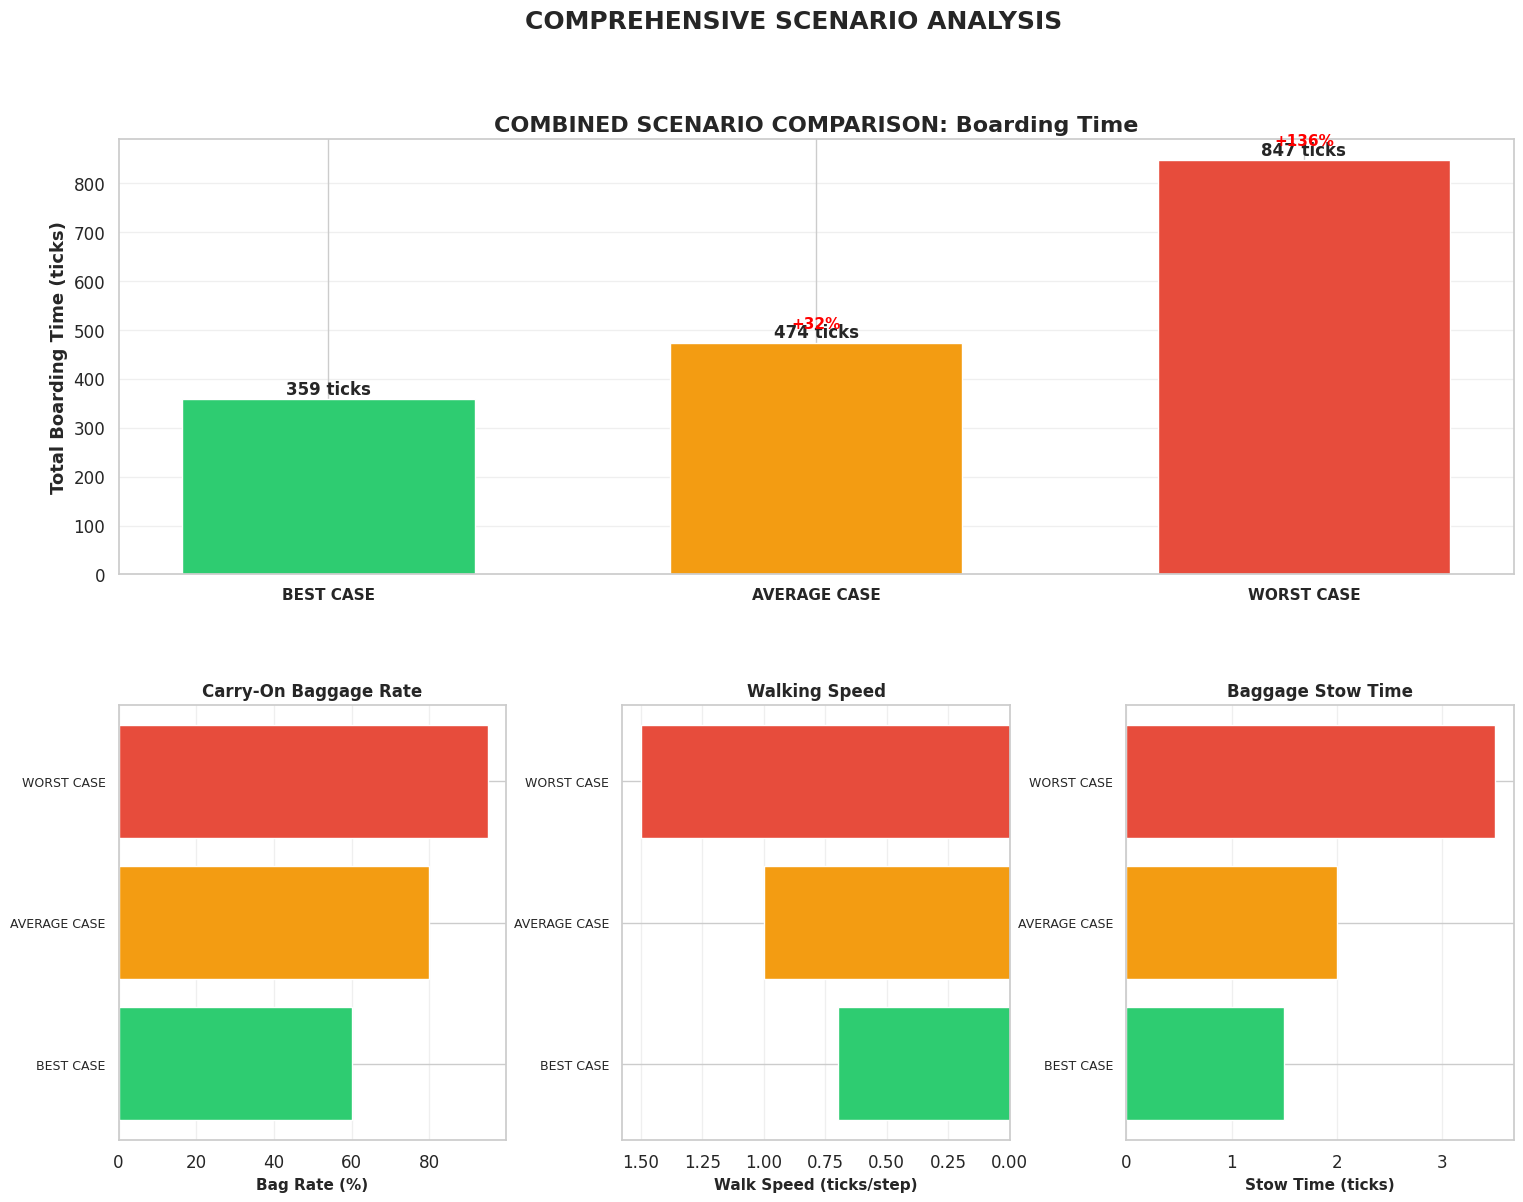

KEY FINDINGS:
🟢 BEST CASE:  359 ticks
🟡 AVERAGE:    474 ticks (+32%)
🔴 WORST CASE: 847 ticks (+136%)

💡 OPERATIONAL INSIGHT:
   Holiday/family flights can take 136% LONGER to board!
   Airlines should allocate 6-8 extra minutes for holiday routes.
   Business routes can use tighter turnaround schedules.


In [18]:
# EXPERIMENT 5: Combined Scenario Analysis - Worst Case vs Best Case

print("\n" + "=" * 100)
print("EXPERIMENT 5: COMBINED WORST-CASE vs BEST-CASE SCENARIOS")
print("=" * 100)
print()

combined_scenarios = {
    "BEST CASE\n(Business, Fast, Experienced)": {
        "p_have_bag": 0.6,
        "walk_mean": 0.7,
        "walk_sd": 0.15,
        "stow_mean": 1.5,
        "stow_sd": 0.3,
        "description": "Morning business flight\nFew bags, fast walkers",
    },
    "AVERAGE CASE\n(Standard conditions)": {
        "p_have_bag": 0.8,
        "walk_mean": 1.0,
        "walk_sd": 0.2,
        "stow_mean": 2.0,
        "stow_sd": 0.5,
        "description": "Typical weekday flight",
    },
    "WORST CASE\n(Holiday, Families, Inexperienced)": {
        "p_have_bag": 0.95,
        "walk_mean": 1.5,
        "walk_sd": 0.3,
        "stow_mean": 3.5,
        "stow_sd": 1.0,
        "description": "Holiday travel\nMany bags, slow walkers",
    },
}

combined_results = []

for scenario_name, params in combined_scenarios.items():
    print(f"Running {scenario_name.split(chr(10))[0]}...")

    config = SimConfig(seed=174, num_passengers=180)
    config.p_have_bag = params["p_have_bag"]
    config.walk_mean = params["walk_mean"]
    config.walk_sd = params["walk_sd"]
    config.stow_mean = params["stow_mean"]
    config.stow_sd = params["stow_sd"]

    metrics, plane, result = run_once(
        cfg=config,
        boarding_strategy=STRATEGIES["steffen"],
        save_frames=False,
        perfect_queue=True,
    )

    combined_results.append(
        {
            "Scenario": scenario_name,
            "Description": params["description"],
            "Bag Rate": f"{params['p_have_bag']*100:.0f}%",
            "Walk Speed": params["walk_mean"],
            "Stow Time": params["stow_mean"],
            "Total Ticks": metrics.total_ticks,
        }
    )

combined_exp_df = pd.DataFrame(combined_results)
print()
print(
    combined_exp_df[
        ["Scenario", "Bag Rate", "Walk Speed", "Stow Time", "Total Ticks"]
    ].to_string(index=False)
)
print()

# Comprehensive visualization
fig = plt.figure(figsize=(18, 13))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Plot 1: Total boarding time comparison
ax1 = fig.add_subplot(gs[0, :])
colors_combined = ["#2ECC71", "#F39C12", "#E74C3C"]
bars = ax1.bar(
    range(len(combined_exp_df)),
    combined_exp_df["Total Ticks"],
    color=colors_combined,
    width=0.6,
)
ax1.set_xticks(range(len(combined_exp_df)))
ax1.set_xticklabels(
    [s.split("\n")[0] for s in combined_exp_df["Scenario"]],
    fontsize=11,
    fontweight="bold",
)
ax1.set_ylabel("Total Boarding Time (ticks)", fontsize=13, fontweight="bold")
ax1.set_title(
    "COMBINED SCENARIO COMPARISON: Boarding Time", fontsize=16, fontweight="bold"
)
ax1.grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars, combined_exp_df["Total Ticks"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        val + 10,
        f"{val} ticks",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

# Add percentage differences
best_time = combined_exp_df.iloc[0]["Total Ticks"]
for i, (bar, val) in enumerate(zip(bars, combined_exp_df["Total Ticks"])):
    if i > 0:
        pct_diff = ((val - best_time) / best_time) * 100
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            val + 30,
            f"+{pct_diff:.0f}%",
            ha="center",
            fontsize=11,
            color="red",
            fontweight="bold",
        )

# Plot 2: Parameter breakdown - Bag Rate
ax2 = fig.add_subplot(gs[1, 0])
ax2.barh(
    range(len(combined_exp_df)),
    [float(s.strip("%")) for s in combined_exp_df["Bag Rate"]],
    color=colors_combined,
)
ax2.set_yticks(range(len(combined_exp_df)))
ax2.set_yticklabels([s.split("\n")[0] for s in combined_exp_df["Scenario"]], fontsize=9)
ax2.set_xlabel("Bag Rate (%)", fontsize=11, fontweight="bold")
ax2.set_title("Carry-On Baggage Rate", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="x")

# Plot 3: Parameter breakdown - Walk Speed
ax3 = fig.add_subplot(gs[1, 1])
ax3.barh(
    range(len(combined_exp_df)), combined_exp_df["Walk Speed"], color=colors_combined
)
ax3.set_yticks(range(len(combined_exp_df)))
ax3.set_yticklabels([s.split("\n")[0] for s in combined_exp_df["Scenario"]], fontsize=9)
ax3.set_xlabel("Walk Speed (ticks/step)", fontsize=11, fontweight="bold")
ax3.set_title("Walking Speed", fontsize=12, fontweight="bold")
ax3.invert_xaxis()
ax3.grid(True, alpha=0.3, axis="x")

# Plot 4: Parameter breakdown - Stow Time
ax4 = fig.add_subplot(gs[1, 2])
ax4.barh(
    range(len(combined_exp_df)), combined_exp_df["Stow Time"], color=colors_combined
)
ax4.set_yticks(range(len(combined_exp_df)))
ax4.set_yticklabels([s.split("\n")[0] for s in combined_exp_df["Scenario"]], fontsize=9)
ax4.set_xlabel("Stow Time (ticks)", fontsize=11, fontweight="bold")
ax4.set_title("Baggage Stow Time", fontsize=12, fontweight="bold")
ax4.grid(True, alpha=0.3, axis="x")

plt.suptitle("COMPREHENSIVE SCENARIO ANALYSIS", fontsize=18, fontweight="bold", y=0.98)
plt.savefig("../figures/comprehensive_scenario_analysis.png", dpi=300)
plt.show()

print("=" * 100)
print("KEY FINDINGS:")
print("=" * 100)
best = combined_exp_df.iloc[0]
worst = combined_exp_df.iloc[2]
avg = combined_exp_df.iloc[1]

print(f"🟢 BEST CASE:  {best['Total Ticks']} ticks")
print(
    f"🟡 AVERAGE:    {avg['Total Ticks']} ticks (+{((avg['Total Ticks']-best['Total Ticks'])/best['Total Ticks']*100):.0f}%)"
)
print(
    f"🔴 WORST CASE: {worst['Total Ticks']} ticks (+{((worst['Total Ticks']-best['Total Ticks'])/best['Total Ticks']*100):.0f}%)"
)
print()
print(f"💡 OPERATIONAL INSIGHT:")
print(
    f"   Holiday/family flights can take {((worst['Total Ticks']-best['Total Ticks'])/best['Total Ticks']*100):.0f}% LONGER to board!"
)
print(
    f"   Airlines should allocate {((worst['Total Ticks']-avg['Total Ticks'])/60):.0f}-{((worst['Total Ticks']-best['Total Ticks'])/60):.0f} extra minutes for holiday routes."
)
print(f"   Business routes can use tighter turnaround schedules.")
print("=" * 100)


EXPERIMENT 6: STRATEGY ROBUSTNESS ACROSS OPERATIONAL CONDITIONS
Testing all strategies under best-case, average, and worst-case conditions

Running front_to_back under Best Case...
Running back_to_front under Best Case...
Running random under Best Case...
Running wilma under Best Case...
Running steffen under Best Case...
Running front_to_back under Average...
Running back_to_front under Average...
Running random under Average...
Running wilma under Average...
Running steffen under Average...
Running front_to_back under Worst Case...
Running back_to_front under Worst Case...
Running random under Worst Case...
Running wilma under Worst Case...
Running steffen under Worst Case...

Strategy Performance Matrix:
Scenario       Best Case  Average  Worst Case
Strategy                                     
Back To Front        413      566         954
Front To Back        413      566         954
Random               344      418         736
Steffen              362      474         844
Wilma 

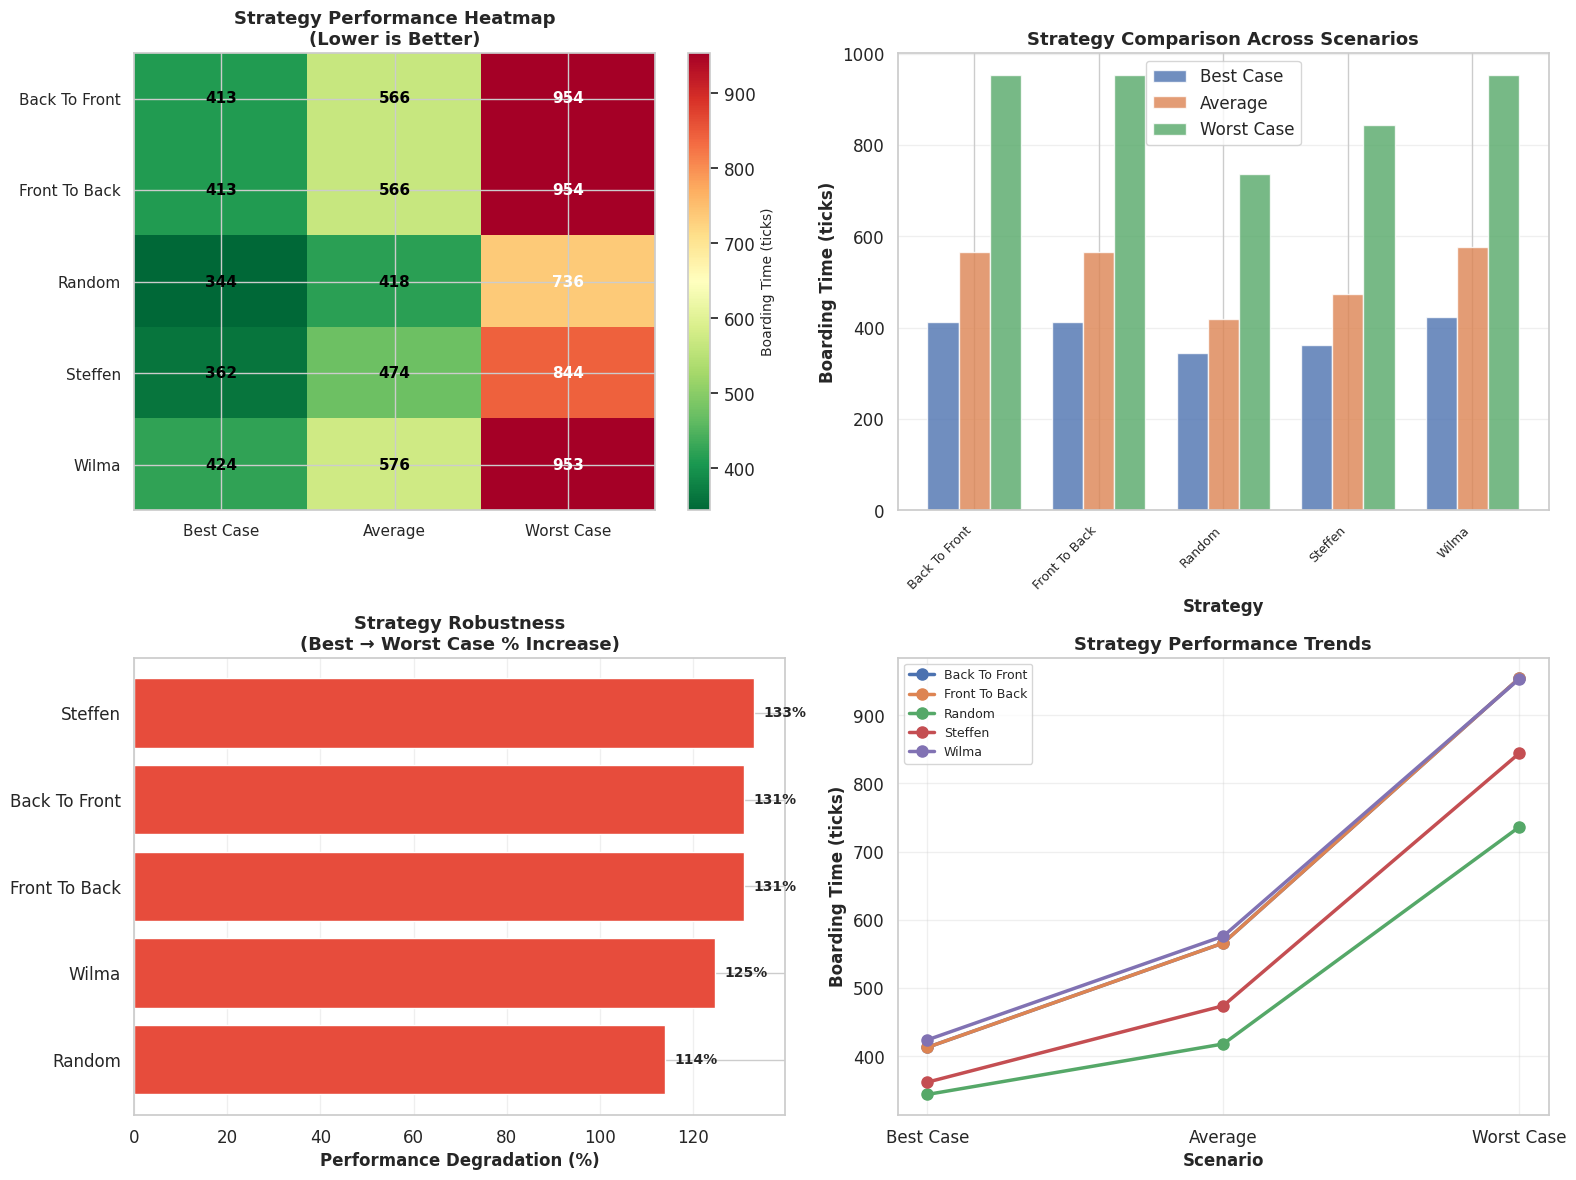

STRATEGIC INSIGHTS:
🏆 Best Overall Performance: Random (344 ticks)
📊 Best Average Performance: Random (499 ticks avg)
🛡️  Most Robust Strategy: Random (114% degradation)
⚠️  Least Robust Strategy: Steffen (133% degradation)

💡 RECOMMENDATION:
   Use Random for consistent performance across all conditions
   Random shows best resilience to operational challenges


In [19]:
# EXPERIMENT 6: Strategy Performance Across Different Scenarios

print("\n" + "=" * 100)
print("EXPERIMENT 6: STRATEGY ROBUSTNESS ACROSS OPERATIONAL CONDITIONS")
print("=" * 100)
print("Testing all strategies under best-case, average, and worst-case conditions")
print()

scenario_configs = {
    "Best Case": {"p_have_bag": 0.6, "walk_mean": 0.7, "stow_mean": 1.5},
    "Average": {"p_have_bag": 0.8, "walk_mean": 1.0, "stow_mean": 2.0},
    "Worst Case": {"p_have_bag": 0.95, "walk_mean": 1.5, "stow_mean": 3.5},
}

strategy_scenario_results = []

for scenario_name, scenario_params in scenario_configs.items():
    for strategy_name, strategy_func in STRATEGIES.items():
        print(f"Running {strategy_name} under {scenario_name}...")

        config = SimConfig(seed=174, num_passengers=180)
        config.p_have_bag = scenario_params["p_have_bag"]
        config.walk_mean = scenario_params["walk_mean"]
        config.stow_mean = scenario_params["stow_mean"]

        metrics, plane, result = run_once(
            cfg=config,
            boarding_strategy=strategy_func,
            save_frames=False,
            perfect_queue=True,
        )

        strategy_scenario_results.append(
            {
                "Strategy": strategy_name.replace("_", " ").title(),
                "Scenario": scenario_name,
                "Total Ticks": metrics.total_ticks,
            }
        )

strategy_scenario_df = pd.DataFrame(strategy_scenario_results)

# Create pivot table for heatmap
pivot_df = strategy_scenario_df.pivot(
    index="Strategy", columns="Scenario", values="Total Ticks"
)
pivot_df = pivot_df[["Best Case", "Average", "Worst Case"]]  # Ensure column order

print()
print("Strategy Performance Matrix:")
print(pivot_df.to_string())
print()

# Comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Heatmap
ax1 = axes[0, 0]
im = ax1.imshow(pivot_df.values, cmap="RdYlGn_r", aspect="auto")
ax1.set_xticks(range(len(pivot_df.columns)))
ax1.set_xticklabels(pivot_df.columns, fontsize=11)
ax1.set_yticks(range(len(pivot_df.index)))
ax1.set_yticklabels(pivot_df.index, fontsize=11)
ax1.set_title(
    "Strategy Performance Heatmap\n(Lower is Better)", fontsize=13, fontweight="bold"
)

# Add text annotations
for i in range(len(pivot_df.index)):
    for j in range(len(pivot_df.columns)):
        val = pivot_df.values[i, j]
        ax1.text(
            j,
            i,
            f"{val:.0f}",
            ha="center",
            va="center",
            color="white" if val > pivot_df.values.mean() else "black",
            fontsize=11,
            fontweight="bold",
        )

cbar = plt.colorbar(im, ax=ax1)
cbar.set_label("Boarding Time (ticks)", fontsize=10)

# Plot 2: Grouped bar chart
ax2 = axes[0, 1]
x = np.arange(len(pivot_df.index))
width = 0.25

for i, scenario in enumerate(pivot_df.columns):
    offset = (i - 1) * width
    bars = ax2.bar(x + offset, pivot_df[scenario], width, label=scenario, alpha=0.8)

ax2.set_xlabel("Strategy", fontsize=12, fontweight="bold")
ax2.set_ylabel("Boarding Time (ticks)", fontsize=12, fontweight="bold")
ax2.set_title("Strategy Comparison Across Scenarios", fontsize=13, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(pivot_df.index, rotation=45, ha="right", fontsize=9)
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

# Plot 3: Performance degradation (% increase from best to worst)
ax3 = axes[1, 0]
degradation = (
    (pivot_df["Worst Case"] - pivot_df["Best Case"]) / pivot_df["Best Case"] * 100
).sort_values()
colors_deg = [
    "#2ECC71" if x < 50 else "#F39C12" if x < 100 else "#E74C3C" for x in degradation
]
bars = ax3.barh(degradation.index, degradation.values, color=colors_deg)
ax3.set_xlabel("Performance Degradation (%)", fontsize=12, fontweight="bold")
ax3.set_title(
    "Strategy Robustness\n(Best → Worst Case % Increase)",
    fontsize=13,
    fontweight="bold",
)
ax3.grid(True, alpha=0.3, axis="x")

for bar, val in zip(bars, degradation.values):
    ax3.text(
        val + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f}%",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

# Plot 4: Line plot showing strategy trends
ax4 = axes[1, 1]
for strategy in pivot_df.index:
    ax4.plot(
        pivot_df.columns,
        pivot_df.loc[strategy],
        marker="o",
        linewidth=2.5,
        markersize=8,
        label=strategy,
    )

ax4.set_xlabel("Scenario", fontsize=12, fontweight="bold")
ax4.set_ylabel("Boarding Time (ticks)", fontsize=12, fontweight="bold")
ax4.set_title("Strategy Performance Trends", fontsize=13, fontweight="bold")
ax4.legend(loc="best", fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/strategy_robustness_analysis.png", dpi=300)
plt.show()

# Statistical summary
print("=" * 100)
print("STRATEGIC INSIGHTS:")
print("=" * 100)

best_overall = pivot_df.min().min()
worst_overall = pivot_df.max().max()
best_strategy_avg = pivot_df.mean(axis=1).idxmin()
most_robust = degradation.idxmin()

print(
    f"🏆 Best Overall Performance: {pivot_df.min(axis=1).idxmin()} ({pivot_df.min(axis=1).min():.0f} ticks)"
)
print(
    f"📊 Best Average Performance: {best_strategy_avg} ({pivot_df.loc[best_strategy_avg].mean():.0f} ticks avg)"
)
print(
    f"🛡️  Most Robust Strategy: {most_robust} ({degradation[most_robust]:.0f}% degradation)"
)
print(
    f"⚠️  Least Robust Strategy: {degradation.idxmax()} ({degradation.max():.0f}% degradation)"
)
print()
print("💡 RECOMMENDATION:")
print(f"   Use {best_strategy_avg} for consistent performance across all conditions")
print(f"   {most_robust} shows best resilience to operational challenges")
print("=" * 100)